In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import gc
import os
import importlib
from importlib import reload
import cv2
from tqdm.auto import tqdm
from collections import defaultdict

import ast
import seaborn as sns
import numpy as np
import os
import sys
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import hashlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import roc_auc_score


os.chdir('..') # 상위 경로 이동
print("현재 경로:", os.getcwd())
root_dir = '/home/DAHS1/gangmin/my_research/'

현재 경로: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning


- CXR 전처리는 맨 밑에서 확인할 것

In [2]:
sequential_df_med = pd.read_feather(root_dir + "processed/processed_1013/sequential_df_med.ftr")
sequential_df_output = pd.read_feather(root_dir + "processed/processed_1013/sequential_df_output.ftr")
# imputed_df_chart = pd.read_feather(root_dir + "processed/imputed_df_chart_1223.ftr")
imputed_df_chart = pd.read_feather(root_dir + "processed/imputed_df_chart_0219.ftr")

sequential_df_proc = pd.read_feather(root_dir + "processed/sequential_df_proc.ftr")
sequential_df_reports = pd.read_feather(root_dir + "processed/sequential_df_reports.ftr")

# imputed_cxr_df = pd.read_feather(root_dir + '/processed/imputed_cxr_df_20260126.ftr') # edema_pathophyisology
imputed_cxr_df = pd.read_feather(root_dir + '/processed/imputed_cxr_df_20260220.ftr')
imputed_text_df = pd.read_feather(root_dir+'/processed/imputed_text_df.ftr')

In [3]:
# missing_mask 처리
# sequential_df_med['observed_mask'] = sequential_df_med['input_amount'].notna().astype(int)
# sequential_df_output['observed_mask'] = sequential_df_output['urine_output'].notna().astype(int)
# sequential_df_proc['observed_mask'] = sequential_df_proc['procedure_flag']

In [4]:
# 결측값 제로 패딩
sequential_df_output['urine_output'] = sequential_df_output['urine_output'].fillna(0)
sequential_df_med['input_amount'] = sequential_df_med['input_amount'].fillna(0)

In [5]:
sequential_df_med

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,input_amount
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,221794,0.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,221794,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,221794,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,221794,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,221794,0.0
...,...,...,...,...,...,...,...
16187705,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225974,0.0
16187706,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225974,0.0
16187707,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225974,0.0
16187708,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225974,0.0


In [6]:
sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0.000000
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0.000000
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0.000000
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0.000000
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


In [7]:
sequential_df_proc

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,procedure_flag
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,225402,0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,225402,0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,225402,1
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,225402,1
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,225402,0
...,...,...,...,...,...,...,...
3237537,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225794,0
3237538,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225794,0
3237539,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225794,0
3237540,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225794,0


In [8]:
# def add_input_recency(df, hour_slot, value_col, group_cols = ("stay_id", "itemid"), normalize=False):
#     """
#     각 그룹별로 input_amount > 0인 마지막 시점으로부터의 시간 차이를 계산.
#     """
#     df["_positive"] = df[value_col] > 0.0

#     def _compute_recency(g):
#         t = g[hour_slot].to_numpy()
#         pos = g["_positive"].to_numpy()

#         if not pos.any():
#             g["recency_pos"] = np.nan
#             return g

#         NEG = -10**9
#         last = np.where(pos, t, NEG)
#         last = np.maximum.accumulate(last)
#         last = np.where(last < NEG // 10, -1, last)
#         rec = t - last
#         rec = rec.astype(float)

#         first_pos_idx = np.argmax(pos)
#         rec[:first_pos_idx] = np.nan

#         g["recency_pos"] = rec
#         return g

#     df = df.groupby(list(group_cols), group_keys=False).apply(_compute_recency)
#     df["recency_mask"] = df["recency_pos"].isna().astype(int)

#     if normalize:
#         max_time = df.groupby("stay_id")[hour_slot].transform("max").astype(float)
#         df["recency_pos_norm"] = (df["recency_pos"] / (max_time + 1e-6)).clip(0, 1)

#     return df.drop(columns=["_positive"])

# sequential_df_med = add_input_recency(sequential_df_med, 'hour_slot', 'input_amount', normalize=True)

In [9]:
# def add_procedure_recency(df, hour_slot, flag_col="procedure_flag", group_cols=("stay_id", "itemid"), normalize=False):    
#     """
#     각 그룹별로 procedure_flag > 0인 마지막 시점으로부터의 시간 차이를 계산.
#     """
#     df["_positive"] = df[flag_col] == 1 

#     def _compute_recency(g):
#         t = g[hour_slot].to_numpy()
#         pos = g["_positive"].to_numpy()

#         if not pos.any():
#             g["recency_pos"] = np.nan
#             return g

#         NEG = -10**9
#         last = np.where(pos, t, NEG)
#         last = np.maximum.accumulate(last)
#         last = np.where(last < NEG // 10, -1, last)
#         rec = t - last
#         rec = rec.astype(float)

#         first_pos_idx = np.argmax(pos)
#         rec[:first_pos_idx] = np.nan

#         g["recency_pos"] = rec
#         return g

#     df = df.groupby(list(group_cols), group_keys=False).apply(_compute_recency)
#     df["recency_mask"] = df["recency_pos"].isna().astype(int)

#     if normalize:
#         max_time = df.groupby("stay_id")[hour_slot].transform("max").astype(float)
#         df["recency_pos_norm"] = (df["recency_pos"] / (max_time + 1e-6)).clip(0, 1)

#     return df.drop(columns=["_positive"])

# sequential_df_proc = add_procedure_recency(sequential_df_proc, 'hour_slot', 'procedure_flag', normalize=True)

In [10]:
# def add_chart_recency(df, hour_slot, group_cols=("stay_id", "itemid"), normalize=False):
#     def _compute_chart_recency(g):
#         t = g[hour_slot].to_numpy()
#         pos = g["observed_mask"].to_numpy()  # original 값 여부

#         if not pos.any():
#             g["recency_pos"] = np.nan
#             return g

#         NEG = -10**9
#         last = np.where(pos, t, NEG)
#         last = np.maximum.accumulate(last)
#         last = np.where(last < NEG // 10, -1, last)
#         rec = t - last
#         rec = rec.astype(float)

#         # 첫 번째 original 값 등장 이전은 모두 NaN
#         first_pos_idx = np.argmax(pos)
#         rec[:first_pos_idx] = np.nan

#         g["recency_pos"] = rec
#         return g

#     df = df.sort_values(list(group_cols) + [hour_slot]).copy()
#     df = df.groupby(list(group_cols), group_keys=False).apply(_compute_chart_recency)

#     # 결측 여부 마스크 생성
#     df["recency_mask"] = df["recency_pos"].isna().astype(int)

#     if normalize:
#         max_time = df.groupby("stay_id")[hour_slot].transform("max").astype(float)
#         df["recency_pos_norm"] = (df["recency_pos"] / (max_time + 1e-6)).clip(0, 1)

#     return df

In [11]:
# imputed_df_chart = add_chart_recency(imputed_df_chart, hour_slot="hour_slot", normalize=True)
# imputed_df_chart

| Old Label Distribution        | num         |
|---------------|--------------------------|
| 0.0    | 34,879 |
| 2.0  | 11,759 |
| 1.0 | 4,371 |

In [12]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    36390
 1.0    12411
-1.0     4496
Name: count, dtype: int64

In [13]:
imputed_df_chart

,stay_id,itemid,hour_slot,slot_start,value
0,30000646,50963,0,2194-04-29 01:39:22,-2.0
1,30000646,50963,1,2194-04-29 02:39:22,-2.0
2,30000646,50963,2,2194-04-29 03:39:22,-2.0
3,30000646,50963,3,2194-04-29 04:39:22,-2.0
4,30000646,50963,4,2194-04-29 05:39:22,-2.0
...,...,...,...,...,...
25900331,39998622,227456,211,2135-02-20 13:13:55,2.7
25900332,39998622,227456,212,2135-02-20 14:13:55,2.7
25900333,39998622,227456,213,2135-02-20 15:13:55,2.7
25900334,39998622,227456,214,2135-02-20 16:13:55,2.7


In [14]:
# # urine
# def add_output_recency(df, hour_slot, value_col='urine_output', group_col = ("stay_id"), normalize=False):
#     df["_positive"] = df[value_col] > 0.0

#     def _compute_recency(g):
#         t = g[hour_slot].to_numpy()
#         pos = g["_positive"].to_numpy()

#         if not pos.any():
#             g["recency_pos"] = np.nan
#             return g

#         NEG = -10**9
#         last = np.where(pos, t, NEG)
#         last = np.maximum.accumulate(last)
#         last = np.where(last < NEG // 10, -1, last)
#         rec = t - last
#         rec = rec.astype(float)

#         first_pos_idx = np.argmax(pos)
#         rec[:first_pos_idx] = np.nan

#         g["recency_pos"] = rec
#         return g

#     df = df.groupby(group_col, group_keys=False).apply(_compute_recency)
#     df["recency_mask"] = df["recency_pos"].isna().astype(int)

#     if normalize:
#         max_time = df.groupby("stay_id")[hour_slot].transform("max").astype(float)
#         df["recency_pos_norm"] = (df["recency_pos"] / (max_time + 1e-6)).clip(0, 1)

#     return df.drop(columns=["_positive"])

In [15]:
# sequential_df_output = add_output_recency(sequential_df_output, hour_slot="hour_slot", normalize=True)
# sequential_df_output

---

In [16]:
imputed_df_chart.columns

Index(['stay_id', 'itemid', 'hour_slot', 'slot_start', 'value'], dtype='object')

In [17]:
# imputed_df_chart = imputed_df_chart.drop(columns=['original_mask','ffilled_mask','fully_missing', 'recency_mask'])
# imputed_df_chart = imputed_df_chart.drop(columns=['recency_mask', 'recency_pos', 'slot_start'])

In [18]:
df_pivot_value = imputed_df_chart.pivot_table(
    index=['stay_id', 'hour_slot'],   
    columns='itemid',                
    values=['value']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [19]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,137.666667,37.111111,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,141.000000,39.111111,100.0,12.000000,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,140.000000,36.888889,50.0,34.000000,14.0,-2.00,4.200000,-2.0,-2.0,2.7
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,139.000000,36.888889,50.0,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,139.000000,36.944444,50.0,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,139.000000,36.944444,50.0,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7


In [20]:
df_pivot_value.isnull().sum()

stay_id_      0
hour_slot_    0
50963         0
220045        0
220179        0
220180        0
220210        0
220277        0
220645        0
223761        0
223835        0
225624        0
227073        0
227429        0
227442        0
227445        0
227446        0
227456        0
dtype: int64

In [21]:
# df_pivot_value['223835'] = df_pivot_value['223835'] / 100

mask = df_pivot_value['223835'] != -2
df_pivot_value.loc[mask, '223835'] = (df_pivot_value.loc[mask, '223835'] / 100)

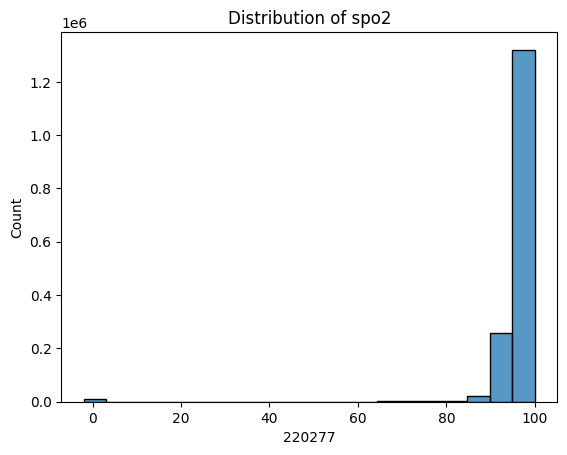

In [22]:
sns.histplot(df_pivot_value['220277'], bins=20)
plt.title('Distribution of spo2')
plt.show()

In [23]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,137.666667,37.111111,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,141.000000,39.111111,1.0,12.000000,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,140.000000,36.888889,0.5,34.000000,14.0,-2.00,4.200000,-2.0,-2.0,2.7
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,139.000000,36.888889,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7


In [24]:
# df_pivot_value['spo2_fio2'] = df_pivot_value["220277"] / df_pivot_value['223835'].replace(0, np.nan)

# # Fio2 col drop
# df_pivoted_chart = df_pivot_value.drop(columns=['223835'])

In [25]:
def calculate_spo2_fio2(spo2, fio2):
    # -2가 있으면 NaN
    if spo2 == -2 or fio2 == -2:
        return np.nan
    # FiO2가 0이면 NaN (division by zero 방지)
    elif fio2 == 0:
        return np.nan
    else:
        return spo2 / fio2

df_pivot_value['spo2_fio2'] = df_pivot_value.apply(
    lambda row: calculate_spo2_fio2(row["220277"], row['223835']), 
    axis=1
)

# df_pivoted_chart = df_pivot_value.drop(columns=['223835'])

In [26]:
df_pivot_value['220277']

0          97.500000
1          94.000000
2          98.000000
3          98.000000
4          94.363636
             ...    
1618766    95.000000
1618767    94.000000
1618768    93.000000
1618769    93.000000
1618770    93.000000
Name: 220277, Length: 1618771, dtype: float64

In [27]:
df_pivoted_chart = df_pivot_value.copy()

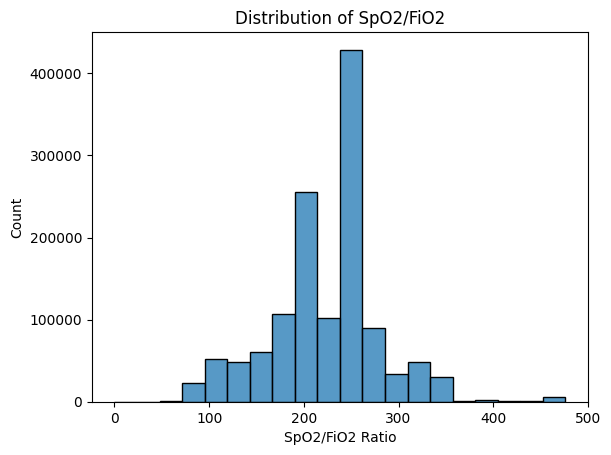

In [28]:
sns.histplot(df_pivoted_chart['spo2_fio2'], bins=20)
plt.title('Distribution of SpO2/FiO2')
plt.xlabel('SpO2/FiO2 Ratio')
plt.show()

In [29]:
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,137.666667,37.111111,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,141.000000,39.111111,1.0,12.000000,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,140.000000,36.888889,0.5,34.000000,14.0,-2.00,4.200000,-2.0,-2.0,2.7,190.000000
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,139.000000,36.888889,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,188.000000
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000


In [30]:
print(f"결측 비율: {len(df_pivoted_chart[df_pivoted_chart['223835']==-2]) / len(df_pivoted_chart)}")

결측 비율: 0.20240849385119947


In [31]:
len(df_pivoted_chart[df_pivoted_chart['223835']==-2])

327653

In [32]:
df_pivoted_chart['spo2_fio2'].isnull().sum()

328996

In [33]:
# 2.35 미만
print(len(df_pivoted_chart[df_pivoted_chart['spo2_fio2'] < 235]) / len(df_pivoted_chart))

# 2.35 이상
print(len(df_pivoted_chart[df_pivoted_chart['spo2_fio2'] >= 235]) / len(df_pivoted_chart))

0.3618967723044211
0.4348650920976469


In [34]:
# 같은 S/F라고 하더라도, FiO2 0.3에서 S/F 250과 FiO2 0.8에서 S/F 250의 치료 강도가 완전히 다르기 때문에, S/F+FiO2 조합을 사용하기로 해서, SpO2는 drop함.
df_pivoted_chart = df_pivot_value.drop(columns=['220277'])

df_pivoted_chart['spo2_fio2'] = (df_pivoted_chart['spo2_fio2'].fillna(-2))
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,137.666667,37.111111,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,141.000000,39.111111,1.0,12.000000,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,140.000000,36.888889,0.5,34.000000,14.0,-2.00,4.200000,-2.0,-2.0,2.7,190.000000
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,139.000000,36.888889,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,188.000000
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000


In [35]:
sequential_df_med

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,input_amount
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,221794,0.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,221794,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,221794,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,221794,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,221794,0.0
...,...,...,...,...,...,...,...
16187705,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225974,0.0
16187706,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225974,0.0
16187707,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225974,0.0
16187708,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225974,0.0


In [36]:
# sequential_df_med = sequential_df_med.drop(columns=['recency_mask', 'recency_pos'])

In [37]:
sequential_df_med.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'slot_start', 'slot_end', 'itemid',
       'input_amount'],
      dtype='object')

In [38]:
# input
df_pivot_input = sequential_df_med.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['input_amount']
).reset_index()

df_pivot_input.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_input.columns.values
]

df_pivot_input

,stay_id_,hour_slot_,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974
0,30000646,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,30000646,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30000646,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,30000646,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,30000646,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1618767,39998622,212,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
1618768,39998622,213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1618769,39998622,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
print(sequential_df_proc['stay_id'].nunique())
print(sequential_df_proc['hadm_id'].nunique())

14146
12985


In [40]:
hadm_df = sequential_df_proc[['hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
hadm_df

,hadm_id,stay_id
0,26184834,37510196
1,23473524,35479615
2,28662225,33987268
3,28662225,38875437
4,20214994,32128372
...,...,...
14141,24096838,33428243
14142,24842066,30988867
14143,20175828,35165301
14144,26785317,32336619


In [41]:
# procedure
df_pivot_proc = sequential_df_proc.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['procedure_flag']
).reset_index()

df_pivot_proc.columns = [
    str(col[1]) if col[0] == 'procedure_flag' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_proc.columns.values
]

df_pivot_proc

,stay_id_,hour_slot_,225402,225794
0,30000646,0,1.0,0.0
1,30000646,1,0.0,0.0
2,30000646,2,0.0,0.0
3,30000646,3,0.0,0.0
4,30000646,4,1.0,0.0
...,...,...,...,...
1618766,39998622,211,0.0,0.0
1618767,39998622,212,0.0,0.0
1618768,39998622,213,0.0,0.0
1618769,39998622,214,0.0,0.0


In [42]:
sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0.000000
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0.000000
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0.000000
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0.000000
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


In [43]:
sequential_df_output = sequential_df_output[['stay_id', 'hour_slot', 'urine_output']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)

In [44]:
sequential_df_output

,stay_id,hour_slot,urine
0,30000646,0,0.000000
1,30000646,1,0.000000
2,30000646,2,0.000000
3,30000646,3,529.277778
4,30000646,4,170.722222
...,...,...,...
1618766,39998622,211,40.473164
1618767,39998622,212,292.896153
1618768,39998622,213,478.226729
1618769,39998622,214,175.741525


In [45]:
df_pivot_input = df_pivot_input.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_proc = df_pivot_proc.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})

In [46]:
med_items = df_pivot_input.drop(columns=['stay_id', 'hour_slot'])
proc_items = df_pivot_proc.drop(columns=['stay_id', 'hour_slot'])
output_items = sequential_df_output.drop(columns=['stay_id', 'hour_slot'])

In [47]:
icu_events = pd.concat([df_pivoted_chart, med_items, proc_items, output_items], axis=1)
icu_events.columns = icu_events.columns.map(str)
icu_events

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,137.666667,-2.000000,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,137.666667,37.111111,-2.0,11.666667,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,529.277778
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,141.000000,39.111111,1.0,12.000000,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,170.722222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,140.000000,36.888889,0.5,34.000000,14.0,-2.00,4.200000,-2.0,-2.0,2.7,190.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.473164
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,139.000000,36.888889,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,188.000000,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,292.896153
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,478.226729
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,139.000000,36.944444,0.5,38.000000,12.0,-2.00,3.900000,-2.0,-2.0,2.7,186.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,175.741525


In [48]:
icu_events = icu_events.rename(columns={'stay_id_':'stay_id', 'hour_slot_':'hour_slot'})
icu_events = hadm_df.merge(icu_events, how='left', on='stay_id')
icu_events = icu_events.sort_values(by=['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
icu_events

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661


In [49]:
icu_events.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220645', '223761', '223835', '225624', '227073',
       '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
       '221662', '221749', '221794', '221906', '221986', '222051', '222056',
       '225168', '225974', '225402', '225794', 'urine'],
      dtype='object')

In [50]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    36390
 1.0    12411
-1.0     4496
Name: count, dtype: int64

In [51]:
test = imputed_cxr_df[imputed_cxr_df['image_path'].notnull()]

In [52]:
test

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Edema,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,1.0,1.0
24,26184834,37510196,24,2131-01-12 04:20:05,2131-01-12 05:20:05,1,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,2131-01-12 04:56:56.359,1.0,1.0
48,26184834,37510196,48,2131-01-13 04:20:05,2131-01-13 05:20:05,1,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,2131-01-13 04:49:18.484,1.0,1.0
78,26184834,37510196,78,2131-01-14 10:20:05,2131-01-14 11:20:05,1,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,2131-01-14 10:34:28.765,-1.0,1.0
96,26184834,37510196,96,2131-01-15 04:20:05,2131-01-15 05:20:05,1,files/p10/p10001884/s50376803/469d0d94-3dad506...,2131-01-15 04:45:09.078,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
1618525,20175828,35165301,81,2197-08-07 09:02:00,2197-08-07 10:02:00,1,files/p19/p19999287/s52519175/f7e95a22-cb95805...,2197-08-07 09:06:37.796,0.0,1.0
1618543,20175828,35165301,99,2197-08-08 03:02:00,2197-08-08 04:02:00,1,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,2197-08-08 03:15:49.890,0.0,1.0
1618565,26785317,32336619,8,2148-11-19 22:23:43,2148-11-19 23:23:43,1,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,2148-11-19 22:47:03.375,0.0,1.0
1618730,23865745,36195440,6,2145-11-03 04:59:00,2145-11-03 05:59:00,1,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,2145-11-03 05:05:07.625,0.0,1.0


In [53]:
# 리샘플링 데이터셋에 라벨 할당
def static_cxr_edema_labeling(df, col, identifier, limit_hours=24):
    processed_list = []

    for stay_id, group in df.groupby(identifier):
        group = group.copy()
        
        current_label = None
        label_start_hour = None

        label_source = [None] * len(group)

        # cxr 라벨 기준 라벨 추출
        for i, (idx, row) in enumerate(group.iterrows()):
            if row['cxr_flag']==1 and not pd.isna(row[col]):
                current_label = row[col]
                label_start_hour = row['hour_slot']

                group.at[idx, col] = current_label
                label_source[i] = 'original'

            elif current_label is not None:
                hour_diff = row['hour_slot'] - label_start_hour

                # label forward-fill
                if hour_diff <= limit_hours:
                    group.at[idx, col] = current_label
                    label_source[i] = 'ffilled'

                else: 
                    current_label = None
                    label_start_hour = None
        
        group['label_source'] = label_source
        processed_list.append(group)
    df = pd.concat(processed_list).sort_index()
    return df

# label_imputed_cxr = static_cxr_edema_labeling(imputed_cxr_df, col='edema_pathophysiology', identifier='stay_id', limit_hours=0)
label_imputed_cxr = static_cxr_edema_labeling(imputed_cxr_df, col='Edema', identifier='stay_id', limit_hours=24)

In [54]:
label_imputed_cxr['Edema'].value_counts()

Edema
 0.0    654396
 1.0    231710
-1.0     83405
Name: count, dtype: int64

In [55]:
label_imputed_cxr['Edema'].isnull().sum()

649260

In [56]:
label_imputed_cxr['Edema'].notnull().sum()

969511

In [57]:
# # old
# label_imputed_cxr['edema_pathophysiology'].value_counts()

In [58]:
# # Mew
# label_imputed_cxr['edema_pathophysiology'].value_counts()

In [59]:
label_imputed_cxr.to_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260222.ftr')

In [60]:
# stay_id별 라벨 정리
labeling = label_imputed_cxr[['stay_id', 'hour_slot', 'Edema', 'label_source']]
labeling

,stay_id,hour_slot,Edema,label_source
0,37510196,0,1.0,original
1,37510196,1,1.0,ffilled
2,37510196,2,1.0,ffilled
3,37510196,3,1.0,ffilled
4,37510196,4,1.0,ffilled
...,...,...,...,...
1618766,36195440,42,0.0,ffilled
1618767,36195440,43,0.0,ffilled
1618768,36195440,44,0.0,ffilled
1618769,36195440,45,0.0,ffilled


---

In [61]:
# label_check_df = labeling.copy()

In [62]:
# label_check_df['prev_label'] = label_check_df.groupby('stay_id')['edema_pathophysiology'].shift(1)

In [63]:
# label_check_df['changed_1_2'] = (
#     ((label_check_df['prev_label'] == 1) & (label_check_df['edema_pathophysiology'] == 2)) |
#     ((label_check_df['prev_label'] == 2) & (label_check_df['edema_pathophysiology'] == 1))
# )

In [64]:
# changed_stay_ids = label_check_df[label_check_df['changed_1_2']]['stay_id'].unique()

In [65]:
# print('cardio-noncardio 라벨의 변화가 있던 stay_id 목록: ', changed_stay_ids)

| 과거 데이터 기준 | num |
|---------------|--------------------------|
| 환자의 입퇴실 이력 이내 라벨 변화가 있었던 환자 수 | 1,041 |
| 환자의 입퇴실 이력 이내 라벨 변화가 있었던 row 수 | 1,456 |


In [66]:
# df_label_changes = label_check_df[label_check_df['changed_1_2']]
# print("환자의 입퇴실 이력 이내 라벨 변화가 있었던 환자 수: ", df_label_changes.stay_id.nunique())
# print("환자의 입퇴실 이력 이내 라벨 변화가 있었던 row 수: ", len(df_label_changes))

---

In [67]:
ts_dataset = icu_events.merge(labeling, how='left', on=['stay_id', 'hour_slot'])
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,label_source
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,None
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,None
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,None
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,None
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,None
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,None


In [68]:
ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220645', '223761', '223835', '225624', '227073',
       '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
       '221662', '221749', '221794', '221906', '221986', '222051', '222056',
       '225168', '225974', '225402', '225794', 'urine', 'Edema',
       'label_source'],
      dtype='object')

In [69]:
feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220645', '223761', '223835', '225624', '227073',
    '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
    '221662', '221749', '221794', '221906', '221986', '222051', '222056',
    '225168', '225974', '225402', '225794', 'urine'
]

In [70]:
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,label_source
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,None
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,None
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,None
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,None
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,None
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,None


In [71]:
def feature_statistics(series):
    nonzero = series[(series != -2) & (~series.isna())] # -2 sentinel
    return pd.Series({
        'min': nonzero.min(),
        'max': nonzero.max(),
        'median': nonzero.median(),
        'mean': nonzero.mean(),
        'std': nonzero.std(),
        'valid count': nonzero.count(),
        'missing count': len(ts_dataset) - nonzero.count(),
        'missing_rate': round((len(ts_dataset) - nonzero.count()) / len(ts_dataset), 4)
    })

stats_df = ts_dataset[feature_cols].apply(feature_statistics).T

In [72]:
ts_dataset[ts_dataset['221794']>=-0]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,label_source
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,None
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,None
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,None
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,None
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,None
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,None


In [73]:
# 225402, 225794는 procedure에 대한 binary
stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
50963,36.00,52217.160000,3998.000000,9080.628890,10960.691012,128245.0,1490526.0,0.9208
220045,1.00,247.500000,86.000000,87.246418,17.969635,1610425.0,8346.0,0.0052
220179,11.00,280.000000,116.000000,118.098244,22.712431,1522526.0,96245.0,0.0595
220180,10.00,175.000000,61.000000,62.912655,15.602443,1522513.0,96258.0,0.0595
220210,1.00,60.000000,20.000000,20.487827,5.859280,1609961.0,8810.0,0.0054
220645,85.00,187.000000,139.000000,138.722953,5.435488,1585659.0,33112.0,0.0205
223761,32.00,42.300000,36.944444,36.999083,0.586862,1575667.0,43104.0,0.0266
223835,0.21,1.000000,0.400000,0.470889,0.154827,1291118.0,327653.0,0.2024
225624,1.00,291.000000,24.000000,31.506651,24.747251,1580841.0,37930.0,0.0234
227073,5.00,50.000000,14.000000,14.522990,3.936657,1580065.0,38706.0,0.0239


In [74]:
print('전체 데이터 수: ', len(ts_dataset)) 
print('spo2_fio2 유효 개수: ', len(ts_dataset[ts_dataset['spo2_fio2']!=-2]))

전체 데이터 수:  1618771
spo2_fio2 유효 개수:  1289775


---

## 검증용 코드

In [75]:
# Old
# def valid_features(row, col):
#     return (row[f'observed_mask_{col}'] == 1) or (row[f'observed_mask_{col}'] == 0 and row[col] != 0)

def valid_features(row, col):
    return (row[col] != -2)


def silver_standard_for_edema_for_analysis(row):
    cpe_score = 0.0
    ncpe_score = 0.0

    # Cardio
    # ----- (1) BNP -----
    if valid_features(row, '227446'):
        bnp = row['227446']
        if bnp > 500: 
            cpe_score += 3.0
        elif bnp >= 250:
            cpe_score += 2.0

    # ----- (2) NTproBNP -----
    if valid_features(row, '50963'):
        nt_bnp = row['50963']
        if nt_bnp > 5000:
            cpe_score += 3.0
        elif nt_bnp > 900:
            cpe_score += 2.0

    # ----- (3) CK-MB -----
    if valid_features(row, '227445'):
        ck_mb = row['227445']
        if ck_mb > 5.0:
            cpe_score += 3.0

    # ----- (4) BUN -----
    if valid_features(row, '225624'):
        bun = row['225624']
        if bun > 30:
            cpe_score += 1.0

    # ----- (5) Troponin-T -----
    if valid_features(row, '227429'):
        troponin = row['227429']
        if troponin >= 0.0135:
            cpe_score += 1.0

    # Non-cardio
    # ----- (1) SpO₂ / FiO₂ -----
    spo2_fio2 = row.get('spo2_fio2', -2)
    fio2 = row.get('223835', -2)

    if valid_features(row, 'spo2_fio2'):
        spo2_fio2 = row.get('spo2_fio2')
        if spo2_fio2 < 150:
            ncpe_score += 2.0
        elif spo2_fio2 < 235: 
            ncpe_score += 1.0
        elif spo2_fio2 < 315:
            ncpe_score += 0.5

    # ----- (2) FiO₂ -----
    if valid_features(row, '223835'):
        fio2 = row.get('223835')
        if fio2 >= 0.6:
            ncpe_score += 1.0
        elif fio2 >= 0.4:
            ncpe_score += 0.5

    # ----- (3) Interaction -----
    if (spo2_fio2 != -2) and (fio2 != -2):
        if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
            ncpe_score += 1.0

        if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
            ncpe_score += 1.0

    # ----- (4) Albumin -----
    if valid_features(row, '227456'):
        albumin = row['227456']
        if albumin < 2.9:
            ncpe_score += 2.0
        elif albumin < 3.5:
            ncpe_score += 1.0

    # # ----- (5) Heart rate -----
    # if valid_features(row, '220045'):
    #     heart_rate = row['220045']
    #     if heart_rate > 120:
    #         ncpe_score += 0.5

    # # ----- (6) Temperature -----
    # if valid_features(row, '223761'):
    #     temperature = row['223761']
    #     if temperature > 38.3:
    #         ncpe_score += 1.0
    
    # -------- 최종 라벨 결정 --------
    score_diff = cpe_score - ncpe_score

    # CPE
    if cpe_score >= 3 and score_diff >= 0.5:
        label = 2.0
    
    # NCPE
    elif ncpe_score >= 2.5 and score_diff <= -0.5:
        label = 1.0
    
    else: 
        label = np.nan

    return pd.Series({
        "label": label,
        "cpe_score": cpe_score,
        "ncpe_score": ncpe_score,
        "score_diff": score_diff,  
    })

In [82]:
test = ts_dataset.copy()

In [77]:
# mask = test['Edema'] == 1.0

# result_df = test.loc[mask].apply(silver_standard_for_edema_for_analysis, axis=1)
# test.loc[mask, result_df.columns] = result_df 

In [83]:
mask = test['Edema'] == 1.0
silver_results = test.loc[mask].apply(silver_standard_for_edema_for_analysis, axis=1)

# Edema=1인 행에만 값 할당
test.loc[mask, 'subtype_label'] = silver_results['label']
test.loc[mask, 'cpe_score'] = silver_results['cpe_score']
test.loc[mask, 'ncpe_score'] = silver_results['ncpe_score']
test.loc[mask, 'score_diff'] = silver_results['score_diff']

# # Edema=0인 행은 NaN 또는 0으로 설정
# test.loc[~mask, 'subtype_label'] = 0.0  # Negative (Edema 없음)
# test.loc[~mask, 'cpe_score'] = 0.0
# test.loc[~mask, 'ncpe_score'] = 0.0
# test.loc[~mask, 'score_diff'] = 0.0

In [85]:
analysis_df = test[test["Edema"]==1]
analysis_df = analysis_df[['stay_id', 'hour_slot', 'Edema', 'subtype_label', 'cpe_score', 'ncpe_score', 'score_diff']].reset_index(drop=True)

/tmp/ipykernel_4043024/249629927.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  patient_temporal_stats = edema_pos.groupby('stay_id').apply(get_temporal_stats)


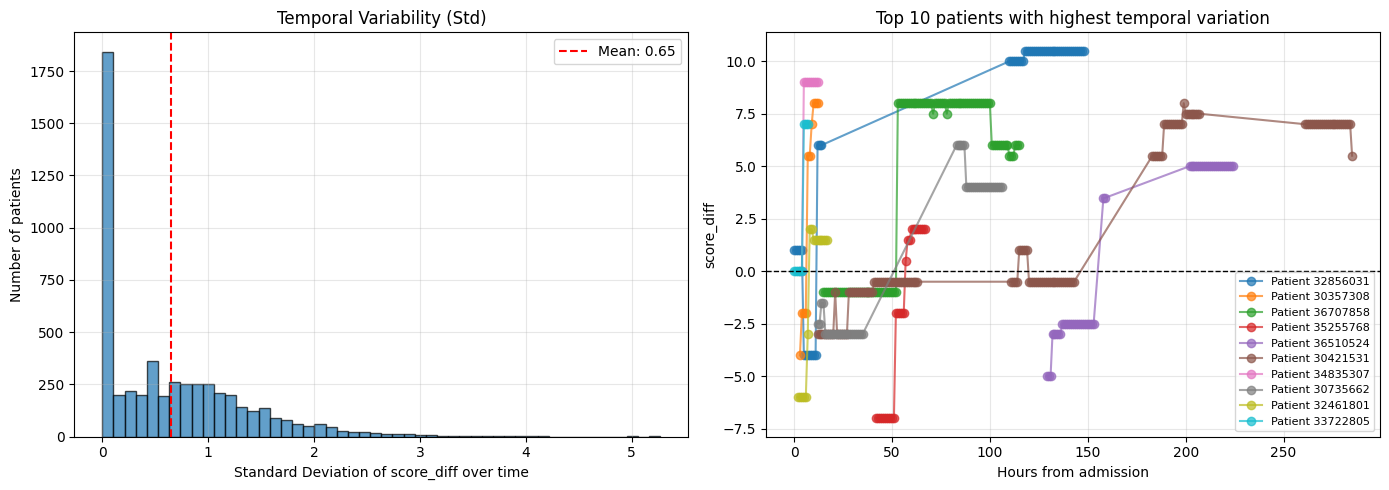

In [99]:
edema_pos = test[test['Edema'] == 1.0].copy()

def get_temporal_stats(group):
    scores = group.sort_values('hour_slot')['score_diff'].dropna()
    
    if len(scores) < 2:
        return pd.Series({
            'n_timepoints': len(scores),
            'mean_score': scores.mean() if len(scores) > 0 else np.nan,
            'std_score': np.nan,
            'range_score': np.nan,
            'initial_score': scores.iloc[0] if len(scores) > 0 else np.nan,
            'final_score': np.nan
        })
    
    return pd.Series({
        'n_timepoints': len(scores),
        'mean_score': scores.mean(),
        'std_score': scores.std(),  # 시간에 따른 변동성
        'range_score': scores.max() - scores.min(),  # 최대-최소 차이
        'initial_score': scores.iloc[0],
        'final_score': scores.iloc[-1]
    })

patient_temporal_stats = edema_pos.groupby('stay_id').apply(get_temporal_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Std 분포
axes[0].hist(patient_temporal_stats['std_score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(patient_temporal_stats['std_score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {patient_temporal_stats["std_score"].mean():.2f}')
axes[0].set_xlabel('Standard Deviation of score_diff over time')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Temporal Variability (Std)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 4) 샘플 환자 시계열 - 변동성 큰 환자 
top_varying = patient_temporal_stats.nlargest(10, 'std_score').index
for stay_id in top_varying:
    patient_data = edema_pos[edema_pos['stay_id'] == stay_id].sort_values('hour_slot')
    axes[1].plot(patient_data['hour_slot'], patient_data['score_diff'], 
                marker='o', alpha=0.7, label=f'Patient {stay_id}')

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Hours from admission')
axes[1].set_ylabel('score_diff')
axes[1].set_title('Top 10 patients with highest temporal variation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
analysis_df = test[(test['Edema'] == 1) & (test['subtype_label'].notna())].copy()

FEATURES = [
    '227446','50963','227445','227429','225624',
    'spo2_fio2','223835','227456',
]

for col in FEATURES:
    valid = analysis_df[analysis_df[col] != -2]
    y = (valid['subtype_label'] == 2).astype(int)
    auc = roc_auc_score(y, valid[col])
    print(col, auc)

227446 0.9522303449631652
50963 0.8679236030308268
227445 0.8084774065659694
227429 0.6831611952265971
225624 0.5938256602382496
spo2_fio2 0.7205533600150158
223835 0.27590023105313854
227456 0.6462666326656994


In [93]:
test.groupby('subtype_label')[['cpe_score','ncpe_score','score_diff']].mean()

,cpe_score,ncpe_score,score_diff
subtype_label,,,
1.0,0.941536,3.763515,-2.821978
2.0,5.381368,2.083744,3.297624


<Axes: xlabel='score_diff', ylabel='Density'>

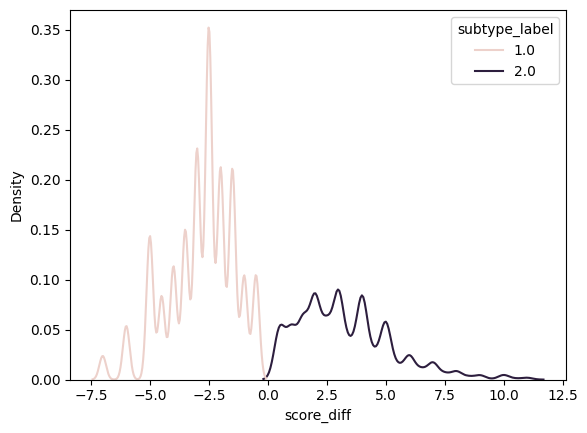

In [94]:
sns.kdeplot(data=test, x="score_diff", hue="subtype_label")

In [95]:
analysis_df = test[(test['Edema'] == 1) & (test['subtype_label'].notna())].copy()

FEATURES = [
    '227446','50963','227445','227429','225624',
    'spo2_fio2','223835','227456'
]

def compute_group_stats(df, features):
    rows = []
    for f in features:
        if f not in df.columns:
            continue
        
        valid = df[df[f] != -2]
        
        for label in [1.0, 2.0]:
            sub = valid[valid['subtype_label'] == label]
            rows.append({
                "feature": f,
                "label": label,
                "median": sub[f].median(),
                "mean": sub[f].mean(),
                "n": len(sub)
            })
    
    return pd.DataFrame(rows)

stats_df = compute_group_stats(analysis_df, FEATURES)
stats_pivot = stats_df.pivot(index='feature', columns='label', values='median')

display(stats_pivot)

label,1.0,2.0
feature,,
223835,0.50,0.40
225624,27.00,35.00
227429,0.04,0.18
227445,3.00,10.00
227446,478.00,7648.00
227456,2.60,3.00
50963,832.00,7994.00
spo2_fio2,192.00,240.00


In [89]:
test.groupby('subtype_label')['score_diff'].describe(
    percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
subtype_label,,,,,,,,,,,,,,
1.0,94657.0,-2.821978,1.414474,-7.0,-7.0,-5.0,-5.0,-3.5,-2.5,-2.0,-1.0,-0.5,-0.5,-0.5
2.0,53628.0,3.297624,2.025826,0.5,0.5,0.5,1.0,2.0,3.0,4.5,6.0,7.0,10.0,11.0


| Old Refined Label Distribution | num |
|---------------|--------------------------|
| 0.0    | 648,644 |
| 2.0  | 235,430 |
| 1.0 | 85,437 |

---

In [107]:
def valid_features(row, col):
    return (row[col] != -2)


def silver_standard_for_edema(row):
    cpe_score = 0.0
    ncpe_score = 0.0

    # Cardio
    # ----- (1) BNP -----
    if valid_features(row, '227446'):
        bnp = row['227446']
        if bnp > 500: 
            cpe_score += 3.0
        elif bnp >= 250:
            cpe_score += 2.0

    # ----- (2) NTproBNP -----
    if valid_features(row, '50963'):
        nt_bnp = row['50963']
        if nt_bnp > 5000:
            cpe_score += 3.0
        elif nt_bnp > 900:
            cpe_score += 2.0

    # ----- (3) CK-MB -----
    if valid_features(row, '227445'):
        ck_mb = row['227445']
        if ck_mb > 5.0:
            cpe_score += 3.0

    # ----- (4) BUN -----
    if valid_features(row, '225624'):
        bun = row['225624']
        if bun > 30:
            cpe_score += 1.0

    # ----- (5) Troponin-T -----
    if valid_features(row, '227429'):
        troponin = row['227429']
        if troponin >= 0.0135:
            cpe_score += 1.0

    # Non-cardio
    # ----- (1) SpO₂ / FiO₂ -----
    spo2_fio2 = row.get('spo2_fio2', -2)
    fio2 = row.get('223835', -2)

    if valid_features(row, 'spo2_fio2'):
        spo2_fio2 = row.get('spo2_fio2')
        if spo2_fio2 < 150:
            ncpe_score += 2.0
        elif spo2_fio2 < 235: 
            ncpe_score += 1.0
        elif spo2_fio2 < 315:
            ncpe_score += 0.5

    # ----- (2) FiO₂ -----
    if valid_features(row, '223835'):
        fio2 = row.get('223835')
        if fio2 >= 0.6:
            ncpe_score += 1.0
        elif fio2 >= 0.4:
            ncpe_score += 0.5

    # ----- (3) Interaction -----
    if (spo2_fio2 != -2) and (fio2 != -2):
        if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
            ncpe_score += 1.0

        if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
            ncpe_score += 1.0

    # ----- (4) Albumin -----
    if valid_features(row, '227456'):
        albumin = row['227456']
        if albumin < 2.9:
            ncpe_score += 2.0
        elif albumin < 3.5:
            ncpe_score += 1.0

    # -------- 최종 라벨 결정 --------
    score_diff = cpe_score - ncpe_score

    if cpe_score >= 3 and score_diff >= 0.5:
        label = 2.0 # cardio

    elif ncpe_score >= 2.5 and score_diff <= -0.5:
        label = 1.0 # Non-cardio

    else:
        label = np.nan

    return pd.Series({
        'label': label,
        'cpe_score': cpe_score,
        'ncpe_score': ncpe_score,
        'score_diff': score_diff
    })

In [108]:
test = ts_dataset.copy()

In [110]:
mask = test['Edema'] == 1.0
silver_results = test.loc[mask].apply(silver_standard_for_edema, axis=1)

# Edema=1인 행에만 값 할당
test.loc[mask, 'subtype_label'] = silver_results['label']
test.loc[mask, 'cpe_score'] = silver_results['cpe_score']
test.loc[mask, 'ncpe_score'] = silver_results['ncpe_score']
test.loc[mask, 'score_diff'] = silver_results['score_diff']

In [111]:
test

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,label_source,subtype_label,cpe_score,ncpe_score,score_diff
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,None,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,None,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,None,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,None,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,None,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,None,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,None,NaN,NaN,NaN,NaN


In [112]:
test['Edema'].value_counts()

Edema
 0.0    654396
 1.0    231710
-1.0     83405
Name: count, dtype: int64

In [113]:
test['subtype_label'].value_counts()

subtype_label
1.0    94657
2.0    53628
Name: count, dtype: int64

In [114]:
test['cpe_score'].value_counts()

cpe_score
0.0     78037
1.0     64470
2.0     25540
5.0     22703
4.0     18711
3.0      6224
7.0      4746
8.0      4449
6.0      3530
10.0     1299
11.0     1102
9.0       899
Name: count, dtype: int64

In [ ]:
test['ncpe_score'].value_counts()

ncpe_score
1.0    40008
2.5    35511
0.0    30091
3.0    29816
2.0    23226
5.0    18375
4.5    16207
3.5    12189
0.5     8195
1.5     6787
7.0     5005
6.0     4312
4.0     1953
5.5       35
Name: count, dtype: int64

In [123]:
test['score_diff'].value_counts()

score_diff
 0.0     28600
-1.0     26589
-2.5     18727
-2.0     18108
 1.0     15965
-1.5     13432
-3.0     12248
-0.5     11071
 2.0     10106
-3.5      7952
-5.0      7643
 0.5      7096
 3.0      7059
 4.0      6794
-4.0      6009
 1.5      5293
 5.0      4693
-4.5      4423
 2.5      4203
-6.0      2857
 3.5      2436
 6.0      1932
 4.5      1782
 7.0      1368
-7.0      1259
 5.5       937
 6.5       760
 8.0       664
 7.5       463
 10.0      383
 9.0       355
 8.5       237
 11.0      154
 10.5       78
 9.5        32
-5.5         2
Name: count, dtype: int64

In [121]:
labeled_ts_dataset = test.copy()

In [122]:
labeled_ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220645', '223761', '223835', '225624', '227073',
       '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
       '221662', '221749', '221794', '221906', '221986', '222051', '222056',
       '225168', '225974', '225402', '225794', 'urine', 'Edema',
       'label_source', 'subtype_label', 'cpe_score', 'ncpe_score',
       'score_diff'],
      dtype='object')

In [124]:
# 시계열 변수는 29개
feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220645', '223761', '223835', '225624', '227073',
    '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
    '221662', '221749', '221794', '221906', '221986', '222051', '222056',
    '225168', '225974', '225402', '225794', 'urine'
]

In [125]:
label_cols = [
    'Edema',
    'subtype_label',
    'score_diff'
]

In [127]:
df_masks = labeled_ts_dataset[['hadm_id', 'stay_id', 'hour_slot'] + feature_cols + label_cols]

In [128]:
# recency도 다 넣어야한다고 생각할 수 있는데, chart(+Lab) 말고는 유의미한가?
df_masks.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220645', '223761', '223835', '225624', '227073',
       '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
       '221662', '221749', '221794', '221906', '221986', '222051', '222056',
       '225168', '225974', '225402', '225794', 'urine', 'Edema',
       'subtype_label', 'score_diff'],
      dtype='object')

In [75]:
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,1.0
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,1.0
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,1.0
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,1.0
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,1.0
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,1.0


In [129]:
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,102.0,53.0,16.0,153.0,36.722222,0.6,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.203390,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,114.406780,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,102.0,53.0,16.0,153.0,36.444444,0.7,20.0,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.779661,NaN,NaN,NaN


---

## For Machine Learning Model Analysis

In [ ]:
# ml_df_masks = ts_dataset[['hadm_id', 'stay_id', 'hour_slot'] + feature_cols + label_cols + observed_mask_cols + imputed_mask_cols]

In [ ]:
# # ML용 데이터
# """
# - 정규화 없음. (Stastic summary 산출 후 변수별 정규화)
# - Observed mask, recency 컬럼 없고 오직 변수만 존재함.
# """
# ml_ts_df = ml_df_masks[['hadm_id', 'stay_id', 'hour_slot'] + feature_cols + observed_mask_cols + imputed_mask_cols + label_cols]
# ml_ts_df = ml_ts_df.rename(columns={'refined_label':'label'})

In [ ]:
# ml_ts_df = ml_ts_df[ml_ts_df['hour_slot'] <= 119]
# ml_ts_df = ml_ts_df.sort_values(['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
# ml_ts_df

,hadm_id,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,227445,observed_mask_50963,observed_mask_227446,observed_mask_227456,observed_mask_220045,observed_mask_220179,observed_mask_220180,observed_mask_220210,observed_mask_220277,observed_mask_220645,observed_mask_223761,observed_mask_225624,observed_mask_227073,observed_mask_227429,observed_mask_227442,observed_mask_227445,observed_mask_221653,observed_mask_221662,observed_mask_urine,observed_mask_221749,observed_mask_221794,observed_mask_221906,observed_mask_221986,observed_mask_222051,observed_mask_222056,observed_mask_225168,observed_mask_225974,observed_mask_225402,observed_mask_225794,imputed_mask_50963,imputed_mask_227446,imputed_mask_227456,imputed_mask_220045,imputed_mask_220179,imputed_mask_220180,imputed_mask_220210,imputed_mask_220277,imputed_mask_220645,imputed_mask_223761,imputed_mask_225624,imputed_mask_227073,imputed_mask_227429,imputed_mask_227442,imputed_mask_227445,label
0,20001305,36916968,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,20001305,36916968,1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,20001305,36916968,2,76.0,89.0,36.0,18.0,100.0,0.0,36.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.787500,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,20001305,36916968,3,73.0,79.0,40.0,25.0,100.0,0.0,36.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.212500,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
4,20001305,36916968,4,66.0,88.0,45.0,20.0,100.0,0.0,36.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.716667,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,91.0,0.0,0.0,29.0,95.0,147.0,39.888889,25.0,12.0,0.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,373.644068,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1039538,29999098,33475199,116,90.0,0.0,0.0,32.0,96.0,147.0,38.666667,25.0,12.0,0.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,317.796610,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1039539,29999098,33475199,117,73.0,0.0,0.0,22.0,95.0,147.0,38.666667,25.0,12.0,0.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,278.389831,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:
# ml_ts_df['label'].value_counts()

label
0.0    389160
2.0    202010
1.0     35723
Name: count, dtype: int64

In [ ]:
# ml_ts_df.to_feather('/home/DAHS1/gangmin/my_research/src/test/ml_ts_df_20260126.ftr')

---

In [130]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")

# procedure는 정규화 대상에서 제외해야 함.
no_proc_feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220645', '223761', '223835', '225624', '227073',
    '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', '221653',
    '221662', '221749', '221794', '221906', '221986', '222051', '222056',
    '225168', '225974', 'urine'
]

itemid_df['itemid'] = itemid_df['itemid'].astype(str)

# 하단 itemid 24개에 50963, procedure 2개에 urine (24 + 1 + 2 + 1 = 28)
itemid_df[itemid_df['itemid'].isin(no_proc_feature_cols)].reset_index(drop=True)

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
2,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
3,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
4,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
5,221653,Dobutamine,Dobutamine,inputevents,Medications,mg,Solution,NaN,NaN
6,221662,Dopamine,Dopamine,inputevents,Medications,mg,Solution,NaN,NaN
7,221749,Phenylephrine,Phenylephrine,inputevents,Medications,mg,Solution,NaN,NaN
8,221794,Furosemide (Lasix),Furosemide (Lasix),inputevents,Medications,mg,Solution,NaN,NaN
9,221906,Norepinephrine,Norepinephrine,inputevents,Medications,mg,Solution,NaN,NaN


- 원본 값과 forward fill된 값(0이 아닌 경우)만을 대상으로 min-max 스케일링을 적용함.
- 의미 없는 결측 대체값(예: 전부 0으로 채운 구간)은 스케일링에서 제외하는 기능을 수행함.

In [ ]:
# def feature_min_max_scaling(df, value_cols=None):
#     """
#     - 완전 결측 -> 통계 왜곡 방지 위해 min/max 계산에서 제외함.
#     - forward-fill된 실수 값 -> 시계열 연속 유지 위해 0 아닌 이상 포함.
#     """
#     df_scaled = df.copy()

#     for col in value_cols:
#         mask_col = f'observed_mask_{col}'
#         has_mask = mask_col in df.columns

#         if has_mask:
#             is_original = df[mask_col] == 0
#             is_ffill = (df[mask_col] == 1) & (df[col] != 0)
#             valid_mask = is_original | is_ffill

#             valid_values = df.loc[valid_mask, col]

#             min_val = valid_values.min()
#             max_val = valid_values.max()

#             scaled_values = df[col].copy()
#             if min_val != max_val:
#                 scaled_values[valid_mask] = (df.loc[valid_mask, col] - min_val) / (max_val - min_val)
#             else:
#                 scaled_values[valid_mask] = 0.0

#         else:
#             valid_values = df[col]
#             min_val = valid_values.min()
#             max_val = valid_values.max()

#             if min_val == max_val:
#                 scaled_values = pd.Series(0.0, index=df.index)
#             else:
#                 scaled_values = (df[col] - min_val) / (max_val - min_val)

#         df_scaled[col] = scaled_values
#     return df_scaled

In [ ]:
# def feature_min_max_scaling(df, value_cols=None, missing_value=-2):
#     """
#     - missing_value(-2)는 min/max 계산에서 제외
#     - scaling도 missing_value는 그대로 유지
#     """

#     df_scaled = df.copy()

#     for col in value_cols:

#         # 유효한 값 (missing_value 제외)
#         valid_mask = df[col] != missing_value
#         valid_values = df.loc[valid_mask, col]

#         # min/max 계산 (missing 제외)
#         if len(valid_values) > 0:
#             min_val = valid_values.min()
#             max_val = valid_values.max()
#         else:
#             # 전부 missing인 경우
#             df_scaled[col] = df[col]
#             continue

#         scaled_values = df[col].copy()

#         if min_val != max_val:
#             scaled_values[valid_mask] = (
#                 (df.loc[valid_mask, col] - min_val) / (max_val - min_val)
#             )
#         else:
#             # 모든 값이 동일한 경우
#             scaled_values[valid_mask] = 0.0

#         # missing 값은 그대로 유지
#         scaled_values[~valid_mask] = missing_value

#         df_scaled[col] = scaled_values

#     return df_scaled

In [ ]:
# df_features = feature_min_max_scaling(df_masks, no_proc_feature_cols)

In [ ]:
# df_features = df_features[['hadm_id', 'stay_id', 'hour_slot'] + feature_cols + label_cols]
# df_features = df_features.rename(columns={'refined_label':'label'})
# df_features

- 향후 feature-specific scaling에도 missing value 제외하고 적용하는 처리 방식 넣을 것.

In [131]:
# 변수별 scaling 별도 적용
def feature_specific_scaling(df, value_cols, proc_cols=None, sentinel=-2):
    """
    <변수별 Scaling 규칙>
    - Labs: Log-transform + Standard Scaler [Lab 변수는 right skewed]
    - etc: Standard scaler
    """
    df_scaled = df.copy()
    proc_cols = set(proc_cols) if proc_cols is not None else set()

    for col in value_cols:

        if col in proc_cols:
            continue
    
        # valid mask 정의
        valid_mask = (df[col] != sentinel)
        valid_values = df.loc[valid_mask, col]

        # Standard Scaling
        mean = valid_values.mean()
        std = valid_values.std(ddof=0)

        scaled_values = df[col].copy()

        if std > 1e-8:
            scaled_values.loc[valid_mask] = (df.loc[valid_mask, col] - mean) / std
        else:
            scaled_values.loc[valid_mask] = 0.0

        scaled_values.loc[~valid_mask] = sentinel
        df_scaled[col] = scaled_values

    return df_scaled

In [ ]:
# # 변수별 scaling 별도 적용
# def feature_specific_scaling(df, value_cols, lab_cols=None):
#     """
#     <변수별 Scaling 규칙>
#     - Labs: Log-transform + Standard Scaler [Lab 변수는 right skewed]
#     - etc: Standard scaler
#     """
#     df_scaled = df.copy()
#     lab_cols = set(lab_cols) if lab_cols is not None else set()

#     for col in value_cols:
#         mask_col = f'observed_mask_{col}'

#         # 1. valid mask 정의
#         valid_mask = ~((df[col] == 0) & (df[mask_col] == 0))
#         valid_values = df.loc[valid_mask, col]

#         # 2. Lab이면 log-transform 적용
#         if col in lab_cols:
#             valid_values = np.log1p(valid_values)
#             transformed_col = np.log1p(df[col])
#         else:
#             transformed_col = df[col].copy()

#         # 3. Standard Scaling
#         mean = valid_values.mean()
#         std = valid_values.std()

#         scaled_values = transformed_col.copy()

#         if std > 0:
#             scaled_values[valid_mask] = (transformed_col[valid_mask] - mean) / std
#         else:
#             scaled_values[valid_mask] = 0.0

#         # 4. 결측값은 0 유지
#         scaled_values[~valid_mask] = 0.0
#         df_scaled[col] = scaled_values

#     return df_scaled

In [132]:
df_features = feature_specific_scaling(df_masks, feature_cols, proc_cols=['225402', '225794'])
df_features = df_features[['hadm_id', 'stay_id', 'hour_slot'] + feature_cols + label_cols]
df_features

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.000000,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.000000,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.000000,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.000000,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.000000,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,-1.349300,-0.708786,-0.635327,-0.765935,2.626636,-0.471764,0.833904,-0.464967,0.375194,-2.0,-1.170099,-2.0,-2.0,-0.191023,-1.135763,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.052296,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,-1.015403,-0.708786,-0.635327,-0.765935,2.626636,-0.945092,1.479785,-0.464967,0.375194,-2.0,-1.170099,-2.0,-2.0,-0.191023,-1.483907,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.216086,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,-1.071053,-0.708786,-0.635327,-0.765935,2.626636,-0.945092,1.479785,-0.464967,0.375194,-2.0,-1.170099,-2.0,-2.0,-0.191023,-1.509074,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.348677,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,-1.015403,-0.708786,-0.635327,-0.765935,2.626636,-0.945092,1.479785,-0.464967,0.375194,-2.0,-1.170099,-2.0,-2.0,-0.191023,-1.559408,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.278482,NaN,NaN,NaN


In [133]:
df_features['Edema'].value_counts(dropna=False)

Edema
 0.0    654396
 NaN    649260
 1.0    231710
-1.0     83405
Name: count, dtype: int64

In [147]:
df_features[(df_features['subtype_label'].isnull()) & (df_features['score_diff_normalized']>0)]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
741,20013839,38119074,22,-2.0,1.154925,0.391933,0.582431,0.258082,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.680157,1.0,NaN,0.0,0.388889
742,20013839,38119074,23,-2.0,0.765379,0.568048,0.838801,0.428751,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.333078,1.0,NaN,0.0,0.388889
743,20013839,38119074,24,-2.0,0.431483,-0.180441,0.197876,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.138667,1.0,NaN,0.0,0.388889
744,20013839,38119074,25,-2.0,1.600121,-0.224469,-0.314865,0.599421,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.318056,1.0,NaN,0.0,0.388889
745,20013839,38119074,26,-2.0,0.097586,-0.400584,-0.571235,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.446171,1.0,NaN,0.0,0.388889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [134]:
df_features['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    1470486
1.0      94657
2.0      53628
Name: count, dtype: int64

In [135]:
df_features = df_features[df_features['hour_slot'] <= 119]
df_features = df_features.sort_values(['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
df_features

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,-2.0,0.208885,1.624739,1.800190,1.452768,1.522779,4.924167,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.734550,0.0,NaN,NaN
1039538,29999098,33475199,116,-2.0,0.153235,1.624739,1.800190,1.964777,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.220562,0.0,NaN,NaN
1039539,29999098,33475199,117,-2.0,-0.792805,1.624739,1.800190,0.258082,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.857884,0.0,NaN,NaN
1039540,29999098,33475199,118,-2.0,-0.514558,1.624739,1.800190,0.770090,1.522779,-0.093103,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.233923,0.0,NaN,NaN


In [ ]:
SCORE_DIFF_MIN = df_features['score_diff'].min()
SCORE_DIFF_MAX = df_features['score_diff'].max()

df_features['score_diff_normalized'] = (df_features['score_diff'] - SCORE_DIFF_MIN) / (SCORE_DIFF_MAX - SCORE_DIFF_MIN)

print(f"Score_diff range: {SCORE_DIFF_MIN} ~ {SCORE_DIFF_MAX}")
print(f"Normalized score_diff range: {df_features['score_diff_normalized'].min():.4f} ~ {df_features['score_diff_normalized'].max():.4f}")

Score_diff range: -7.0 ~ 11.0
Normalized score_diff range: 0.0000 ~ 1.0000


In [146]:
df_features[df_features['score_diff_normalized'].notnull()]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
25,20001305,36916968,25,-2.0,-0.291960,-1.369217,-0.571235,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,1.0,2.0,4.0,0.611111
26,20001305,36916968,26,-2.0,-0.959754,-0.972958,-1.083975,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,1.0,2.0,4.0,0.611111
27,20001305,36916968,27,-2.0,-0.959754,1.272509,0.454246,-0.595266,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.170826,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,3.5,0.583333
28,20001305,36916968,28,-2.0,-0.458909,-1.369217,-1.019883,0.087412,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.658892,1.0,2.0,4.0,0.611111
29,20001305,36916968,29,-2.0,0.208885,-1.545332,-1.003860,0.770090,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.060721,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.703606,1.0,2.0,3.5,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [136]:
df_features['Edema'].value_counts(dropna=False)

Edema
 0.0    438928
 NaN    391667
 1.0    151677
-1.0     57270
Name: count, dtype: int64

In [143]:
tmp = df_features[df_features['Edema']==1]
tmp['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    61541
1.0    54558
2.0    35578
Name: count, dtype: int64

In [144]:
df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_20260324.ftr')

In [ ]:
# DL용 데이터 (Recency 포함)
# df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_1223.ftr')

# 2. CXR 처리

In [12]:
import pandas as pd
from pathlib import PureWindowsPath

In [ ]:
path = "/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/00a00bb82539b548602c42e997818a74.pt"

try:
    img = torch.load(path)
    print("Load success!")
    print("Type:", type(img))
    if hasattr(img, "shape"):
        print("Shape:", img.shape)
except Exception as e:
    print("❌ Load failed:", type(e).__name__, str(e))

Load success!
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 224, 224])


In [6]:
filtered_img_df = pd.read_feather('/home/DAHS1/gangmin/my_research/CXR/filtered_img_df_20260316.ftr')
filtered_img_df

,stay_id,hour_slot,image_path,hash_path
0,37510196,0,files/p10/p10001884/s57156853/9fd47edd-0708720...,C:\Users\gangmin\dahs\my research\final_dfs_20...
1,37510196,24,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,C:\Users\gangmin\dahs\my research\final_dfs_20...
2,37510196,48,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
3,37510196,78,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,C:\Users\gangmin\dahs\my research\final_dfs_20...
4,37510196,96,files/p10/p10001884/s50376803/469d0d94-3dad506...,C:\Users\gangmin\dahs\my research\final_dfs_20...
...,...,...,...,...
53223,35165301,81,files/p19/p19999287/s52519175/f7e95a22-cb95805...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53224,35165301,99,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53225,32336619,8,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53226,36195440,6,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,C:\Users\gangmin\dahs\my research\final_dfs_20...


In [8]:
label_imputed_cxr = pd.read_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260126.ftr')
label_imputed_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing,label_source
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,2.0,1.0,original
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,2.0,0.0,ffilled
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,2.0,0.0,ffilled
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,2.0,0.0,ffilled
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,2.0,0.0,ffilled
...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,0.0,0.0,ffilled
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,0.0,0.0,ffilled
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,0.0,0.0,ffilled
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,0.0,0.0,ffilled


In [9]:
label_imputed_cxr[(label_imputed_cxr['cxr_flag']==1) & (label_imputed_cxr['image_path'].isnull())]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing,label_source


In [10]:
cxr_dataset = label_imputed_cxr.merge(filtered_img_df, how='left', on=['stay_id', 'hour_slot', 'image_path'])
cxr_dataset = cxr_dataset.drop(columns=['hadm_id', 'slot_start', 'slot_end', 'cxrtime'])
cxr_dataset = cxr_dataset.sort_values(['stay_id', 'hour_slot'])
cxr_5days_dataset = cxr_dataset[cxr_dataset['hour_slot'] <= 119].reset_index(drop=True)
cxr_5days_dataset = cxr_5days_dataset.drop(columns=['edema_pathophysiology', 'label_source', 'was_missing', 'image_path'])
cxr_5days_dataset['cxr_flag'] = cxr_5days_dataset['hash_path'].notna().astype(int) # New

In [13]:
cxr_5days_dataset['hash_path'] = cxr_5days_dataset['hash_path'].apply(
    lambda x: PureWindowsPath(x).name if isinstance(x, str) else None
)

In [18]:
print(cxr_5days_dataset['hash_path'][4])
print(cxr_5days_dataset['hash_path'][30])

997317ba341c810ae968d6b5fefcdccf.pt
809650ae1a042763fd81a266b7e27035.pt


In [26]:
test = cxr_5days_dataset[cxr_5days_dataset['hash_path'].notnull()]

In [30]:
broken_files = []
total = len(test)

for i in range(total):
    hash_path = test.iloc[i].hash_path
    full_path = os.path.join("/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/", hash_path)

    try:
        _ = torch.load(full_path)
    except Exception as e:
        broken_files.append(full_path)

print("====" * 20)
print(f"전체 파일 수: {total}")
print(f"손상된 파일 수: {len(broken_files)}")
print("====" * 20)

if len(broken_files) > 0:
    print("\n손상된 파일 목록:")
    for f in broken_files:
        print(f)

전체 파일 수: 37867
손상된 파일 수: 0


In [32]:
cxr_5days_dataset

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [33]:
cxr_5days_dataset.to_feather('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_20260316.ftr')

---

# 아래는 사용하지 않는 과거 코드 모음임.

In [ ]:
renewal_df = pd.read_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_1130.ftr')
old_df = pd.read_parquet('/home/DAHS1/gangmin/my_research/src/test/total_ts_df_5days_0917.parquet')

In [78]:
old_df['label'].value_counts()

label
0.0    414837
2.0    156325
1.0     76713
Name: count, dtype: int64

In [218]:
renewal_df['label'].value_counts()

label
0.0    386723
2.0    192379
1.0     68773
Name: count, dtype: int64

In [213]:
recent_df = recent_df.loc[:, :'label'].sort_values(by=['stay_id', 'hour_slot'])
recent_df = recent_df.drop(columns=['hadm_id']).reset_index(drop=True)
recent_df = recent_df.drop(columns=['227445'])

In [219]:
print(len(old_df))
print(len(recent_df))
print(len(renewal_df))

print(len(old_df)- len(recent_df))
print(len(old_df)- len(renewal_df))

1039542
1035599
1039542
3943
0


In [220]:
renewal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039542 entries, 0 to 1039541
Data columns (total 88 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   hadm_id                  1039542 non-null  int32  
 1   stay_id                  1039542 non-null  int32  
 2   hour_slot                1039542 non-null  int64  
 3   220045                   1039542 non-null  float64
 4   220179                   1039542 non-null  float64
 5   220180                   1039542 non-null  float64
 6   220210                   1039542 non-null  float64
 7   220277                   1039542 non-null  float64
 8   220645                   1039542 non-null  float64
 9   223761                   1039542 non-null  float64
 10  225624                   1039542 non-null  float64
 11  227073                   1039542 non-null  float64
 12  227429                   1039542 non-null  float64
 13  227442                   1039542 non-null 

In [221]:
renewal_df['220045'].isnull().sum()

0

In [ ]:
import torchvision.models as models
import torch.nn as nn
from transformers import AutoModel

In [231]:
language_model = AutoModel.from_pretrained("nlpie/tiny-biobert")

Some weights of BertModel were not initialized from the model checkpoint at nlpie/tiny-biobert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [233]:
demo_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/src/test/demo_df.parquet")
demo_df

,stay_id,gender,age,race,marital_status
0,37510196.0,0,0.263937,1,0
1,35479615.0,0,0.993928,0,3
2,33987268.0,0,0.993928,0,3
3,38875437.0,0,0.993928,0,3
4,32128372.0,0,0.507268,1,0
...,...,...,...,...,...
14141,33428243.0,0,0.446435,1,0
14142,30988867.0,1,-1.135211,5,1
14143,35165301.0,0,0.446435,1,1
14144,32336619.0,1,-1.378542,0,2


In [232]:
for name, param in language_model.named_parameters():
    print(name)

embeddings.word_embeddings.weight
embeddings.position_embeddings.weight
embeddings.token_type_embeddings.weight
embeddings.LayerNorm.weight
embeddings.LayerNorm.bias
encoder.layer.0.attention.self.query.weight
encoder.layer.0.attention.self.query.bias
encoder.layer.0.attention.self.key.weight
encoder.layer.0.attention.self.key.bias
encoder.layer.0.attention.self.value.weight
encoder.layer.0.attention.self.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.attention.output.LayerNorm.weight
encoder.layer.0.attention.output.LayerNorm.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.output.LayerNorm.weight
encoder.layer.0.output.LayerNorm.bias
encoder.layer.1.attention.self.query.weight
encoder.layer.1.attention.self.query.bias
encoder.layer.1.attention.self.key.weight
encoder.layer.1.attention.self.key

In [229]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2) 최신 PyTorch ResNet 구조는 이렇게 구성됨:
#    (conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc)
backbone = nn.Sequential(*list(resnet.children())[:-1])  # fc 제외

# 3) 레이어 이름 전부 출력
for name, param in backbone.named_parameters():
    print(name)


0.weight
1.weight
1.bias
4.0.conv1.weight
4.0.bn1.weight
4.0.bn1.bias
4.0.conv2.weight
4.0.bn2.weight
4.0.bn2.bias
4.0.conv3.weight
4.0.bn3.weight
4.0.bn3.bias
4.0.downsample.0.weight
4.0.downsample.1.weight
4.0.downsample.1.bias
4.1.conv1.weight
4.1.bn1.weight
4.1.bn1.bias
4.1.conv2.weight
4.1.bn2.weight
4.1.bn2.bias
4.1.conv3.weight
4.1.bn3.weight
4.1.bn3.bias
4.2.conv1.weight
4.2.bn1.weight
4.2.bn1.bias
4.2.conv2.weight
4.2.bn2.weight
4.2.bn2.bias
4.2.conv3.weight
4.2.bn3.weight
4.2.bn3.bias
5.0.conv1.weight
5.0.bn1.weight
5.0.bn1.bias
5.0.conv2.weight
5.0.bn2.weight
5.0.bn2.bias
5.0.conv3.weight
5.0.bn3.weight
5.0.bn3.bias
5.0.downsample.0.weight
5.0.downsample.1.weight
5.0.downsample.1.bias
5.1.conv1.weight
5.1.bn1.weight
5.1.bn1.bias
5.1.conv2.weight
5.1.bn2.weight
5.1.bn2.bias
5.1.conv3.weight
5.1.bn3.weight
5.1.bn3.bias
5.2.conv1.weight
5.2.bn1.weight
5.2.bn1.bias
5.2.conv2.weight
5.2.bn2.weight
5.2.bn2.bias
5.2.conv3.weight
5.2.bn3.weight
5.2.bn3.bias
5.3.conv1.weight
5.3.bn1.

- old df가 3천행 정도 많음.
- 성능에는 큰 영향 안 줄 것 같긴 한데 그래도 찾아내야 함

In [57]:
diff_rows = old_df.merge(recent_df, how='left', indicator=True)
missing_in_recent_df = diff_rows[diff_rows['_merge'] == 'left_only']
missing_in_recent_df

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,...,222051,222056,225168,225974,225402,225794,50963,urine,label,_merge
0,30000646,0,0.405680,0.364312,0.336364,0.500000,0.975000,0.516340,0.000000,0.036782,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,NaN,left_only
3,30000646,3,0.348884,0.323420,0.339394,0.389831,0.980000,0.516340,0.496224,0.036782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019892,NaN,left_only
4,30000646,4,0.362899,0.318640,0.311688,0.499230,0.943636,0.549020,0.690399,0.037931,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.006416,2.0,left_only
5,30000646,5,0.374442,0.288476,0.234545,0.549153,0.975000,0.549020,0.690399,0.037931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024659,2.0,left_only
6,30000646,6,0.377282,0.282528,0.218182,0.372881,0.930000,0.549020,0.571737,0.037931,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.012925,2.0,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,39998622,115,0.425963,0.386617,0.400000,0.440678,0.980000,0.539216,0.453074,0.082759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000523,0.0,left_only
1039538,39998622,116,0.417850,0.394052,0.345455,0.457627,0.980000,0.539216,0.453074,0.082759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004612,0.0,left_only
1039539,39998622,117,0.405680,0.371747,0.351515,0.474576,0.980000,0.539216,0.490831,0.082759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015623,0.0,left_only
1039540,39998622,118,0.430020,0.364312,0.309091,0.508475,0.950000,0.558824,0.490831,0.093103,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022373,0.0,left_only


In [65]:
pd.set_option("display.max_columns", 35)

In [66]:
recent_df.head(1)

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
0,30000646,0,0.40568,0.364312,0.336364,0.5,0.975,0.51634,0.0,0.036782,0.155556,0.0,0.296296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [67]:
old_df.head(1)

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
0,30000646,0,0.40568,0.364312,0.336364,0.5,0.975,0.51634,0.0,0.036782,0.155556,0.0,0.296296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN


In [75]:
old_df[(old_df['stay_id']==39998622) & (old_df['hour_slot']==118)]

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
1039540,39998622,118,0.43002,0.364312,0.309091,0.508475,0.95,0.558824,0.490831,0.093103,0.266667,0.0,0.322222,0.0,0.0,0.0,0.0,0.0,0.012289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022373,0.0


In [74]:
recent_df[(recent_df['stay_id']==39998622) & (recent_df['hour_slot']==118)]

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
1035598,39998622,118,0.43002,0.364312,0.309091,0.508475,0.95,0.558824,0.490831,0.093103,0.266667,0.0,0.322222,0.0,0.0,0.0,0.0,0.0,0.012288,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022373,0.0


In [73]:
old_df[old_df['stay_id']==39998622]

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
1039422,39998622,0,0.345842,0.399628,0.384848,0.313559,0.993333,0.493464,0.480043,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001138,NaN
1039423,39998622,1,0.373225,0.475836,0.412121,0.288136,1.000000,0.493464,0.490831,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001815,NaN
1039424,39998622,2,0.389452,0.434944,0.393939,0.237288,1.000000,0.493464,0.490831,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002008,NaN
1039425,39998622,3,0.401623,0.434944,0.393939,0.254237,0.970000,0.493464,0.474649,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001374,0.0
1039426,39998622,4,0.425963,0.434944,0.393939,0.338983,0.980000,0.493464,0.474649,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002173,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,39998622,115,0.425963,0.386617,0.400000,0.440678,0.980000,0.539216,0.453074,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000523,0.0
1039538,39998622,116,0.417850,0.394052,0.345455,0.457627,0.980000,0.539216,0.453074,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.083711,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004612,0.0
1039539,39998622,117,0.405680,0.371747,0.351515,0.474576,0.980000,0.539216,0.490831,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.016000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015623,0.0
1039540,39998622,118,0.430020,0.364312,0.309091,0.508475,0.950000,0.558824,0.490831,0.093103,0.266667,0.0,0.322222,0.0,0.0,0.0,0.0,0.0,0.012289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022373,0.0


In [71]:
recent_df[recent_df['stay_id']==39998622]

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
1035480,39998622,0,0.345842,0.399628,0.384848,0.313559,0.993333,0.493464,0.480043,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001138,NaN
1035481,39998622,1,0.373225,0.475836,0.412121,0.288136,1.000000,0.493464,0.490831,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001815,NaN
1035482,39998622,2,0.389452,0.434944,0.393939,0.237288,1.000000,0.493464,0.490831,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002008,NaN
1035483,39998622,3,0.401623,0.434944,0.393939,0.254237,0.970000,0.493464,0.474649,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001374,0.0
1035484,39998622,4,0.425963,0.434944,0.393939,0.338983,0.980000,0.493464,0.474649,0.049425,0.207407,0.0,0.440741,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002173,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035594,39998622,114,0.430020,0.427509,0.351515,0.406780,0.990000,0.539216,0.453074,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003175,0.0
1035595,39998622,115,0.425963,0.386617,0.400000,0.440678,0.980000,0.539216,0.453074,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000523,0.0
1035596,39998622,116,0.417850,0.394052,0.345455,0.457627,0.980000,0.539216,0.453074,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.083712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004612,0.0
1035597,39998622,117,0.405680,0.371747,0.351515,0.474576,0.980000,0.539216,0.490831,0.082759,0.222222,0.0,0.344444,0.0,0.0,0.0,0.0,0.0,0.016000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015623,0.0


In [ ]:
print(recent_df['220179'].max(), recent_df['220179'].min(), recent_df['220179'].mean())

1.0 0.0 0.32535071814292116


In [53]:
print(old_df['220179'].max(), old_df['220179'].min(), old_df['220179'].mean())


1.0 0.0 0.32524141092592007


In [104]:
img_df = pd.read_parquet('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_0917.parquet')
text_df = pd.read_feather('/home/DAHS1/gangmin/my_research/src/test/1016_final_text_df_5days.ftr')

In [105]:
img_df

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [106]:
text_df

,stay_id,hour_slot,text_flag,parsed_token
0,30000646,0,0,"{'attention_mask': [], 'input_ids': []}"
1,30000646,1,0,"{'attention_mask': [], 'input_ids': []}"
2,30000646,2,0,"{'attention_mask': [], 'input_ids': []}"
3,30000646,3,0,"{'attention_mask': [], 'input_ids': []}"
4,30000646,4,1,"{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1,..."
...,...,...,...,...
1039537,39998622,115,0,"{'attention_mask': [], 'input_ids': []}"
1039538,39998622,116,0,"{'attention_mask': [], 'input_ids': []}"
1039539,39998622,117,0,"{'attention_mask': [], 'input_ids': []}"
1039540,39998622,118,0,"{'attention_mask': [], 'input_ids': []}"


In [107]:
recent_df

,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,label
0,30000646,0,0.405680,0.364312,0.336364,0.500000,0.975000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
1,30000646,1,0.389452,0.319703,0.290909,0.305085,0.940000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
2,30000646,2,0.373225,0.323420,0.284848,0.288136,0.980000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
3,30000646,3,0.348884,0.323420,0.339394,0.389831,0.980000,0.516340,0.496224,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019892,NaN
4,30000646,4,0.362899,0.318640,0.311688,0.499230,0.943636,0.549020,0.690399,0.037931,0.155556,0.000619,0.300000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006416,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035594,39998622,114,0.430020,0.427509,0.351515,0.406780,0.990000,0.539216,0.453074,0.082759,0.222222,0.000000,0.344444,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003175,0.0
1035595,39998622,115,0.425963,0.386617,0.400000,0.440678,0.980000,0.539216,0.453074,0.082759,0.222222,0.000000,0.344444,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000523,0.0
1035596,39998622,116,0.417850,0.394052,0.345455,0.457627,0.980000,0.539216,0.453074,0.082759,0.222222,0.000000,0.344444,0.0,0.0,0.0,0.0,0.0,0.083712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004612,0.0
1035597,39998622,117,0.405680,0.371747,0.351515,0.474576,0.980000,0.539216,0.490831,0.082759,0.222222,0.000000,0.344444,0.0,0.0,0.0,0.0,0.0,0.016000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015623,0.0


In [109]:
merged_recent_df = (recent_df
            .merge(img_df, on=['stay_id', 'hour_slot'], how='outer')
            .merge(text_df, on=['stay_id','hour_slot'], how='outer')
    )

In [223]:
merged_old_df = (old_df
            .merge(img_df, on=['stay_id', 'hour_slot'], how='outer')
            .merge(text_df, on=['stay_id','hour_slot'], how='outer')
    )

In [224]:
merged_renewal_df = (renewal_df
            .merge(img_df, on=['stay_id', 'hour_slot'], how='outer')
            .merge(text_df, on=['stay_id','hour_slot'], how='outer')
    )

In [225]:
merged_renewal_df

,hadm_id,stay_id,hour_slot,220045,220179,220180,220210,220277,220645,223761,225624,227073,227429,227442,227446,227456,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,50963,urine,227445,label,missing_mask_50963,missing_mask_220045,missing_mask_220179,missing_mask_220180,missing_mask_220210,missing_mask_220277,missing_mask_220645,missing_mask_223761,missing_mask_225624,missing_mask_227073,missing_mask_227429,missing_mask_227442,missing_mask_227446,missing_mask_227456,missing_mask_221653,missing_mask_221662,missing_mask_221749,missing_mask_221794,missing_mask_221906,missing_mask_221986,missing_mask_222051,missing_mask_222056,missing_mask_225168,missing_mask_225974,missing_mask_urine,missing_mask_225402,missing_mask_225794,missing_mask_227445,recency_pos_norm_50963,recency_pos_norm_220045,recency_pos_norm_220179,recency_pos_norm_220180,recency_pos_norm_220210,recency_pos_norm_220277,recency_pos_norm_220645,recency_pos_norm_223761,recency_pos_norm_225624,recency_pos_norm_227073,recency_pos_norm_227429,recency_pos_norm_227442,recency_pos_norm_227446,recency_pos_norm_227456,recency_pos_norm_221653,recency_pos_norm_225974,recency_pos_norm_221662,recency_pos_norm_221749,recency_pos_norm_221794,recency_pos_norm_221906,recency_pos_norm_221986,recency_pos_norm_222051,recency_pos_norm_222056,recency_pos_norm_225168,recency_pos_norm_225402,recency_pos_norm_225794,recency_pos_norm_urine,recency_pos_norm_227445,cxr_flag,hash_path,text_flag,parsed_token
0,22795209,30000646,0,0.405680,0.364312,0.336364,0.500000,0.975000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0,None,0,"{'attention_mask': [], 'input_ids': []}"
1,22795209,30000646,1,0.389452,0.319703,0.290909,0.305085,0.940000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.008929,NaN,0.008929,0.008929,NaN,0.008929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008929,NaN,NaN,NaN,0,None,0,"{'attention_mask': [], 'input_ids': []}"
2,22795209,30000646,2,0.373225,0.323420,0.284848,0.288136,0.980000,0.516340,0.000000,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.017857,NaN,0.017857,0.017857,NaN,0.017857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017857,NaN,NaN,NaN,0,None,0,"{'attention_mask': [], 'input_ids': []}"
3,22795209,30000646,3,0.348884,0.323420,0.339394,0.389831,0.980000,0.516340,0.496224,0.036782,0.155556,0.000000,0.296296,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019892,0.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.026786,0.000000,0.026786,0.026786,NaN,0.026786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026786,NaN,0.0,NaN,0,None,0,"{'attention_mask': [], 'input_ids': []}"
4,22795209,30000646,4,0.362899,0.318640,0.311688,0.499230,0.943636,0.549020,0.690399,0.037931,0.155556,0.000619,0.300000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006416,0.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.0,0.0,1,997317ba341c810ae968d6b5fefcdccf.pt,1

In [122]:
check_na_df = merged_recent_df[merged_recent_df['220045'].isnull()]

In [124]:
check_na_df['hour_slot'].value_counts()

hour_slot
119    3943
Name: count, dtype: int64

In [117]:
merged_recent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039542 entries, 0 to 1039541
Data columns (total 34 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   stay_id       1039542 non-null  int32  
 1   hour_slot     1039542 non-null  int64  
 2   220045        1035599 non-null  float64
 3   220179        1035599 non-null  float64
 4   220180        1035599 non-null  float64
 5   220210        1035599 non-null  float64
 6   220277        1035599 non-null  float64
 7   220645        1035599 non-null  float64
 8   223761        1035599 non-null  float64
 9   225624        1035599 non-null  float64
 10  227073        1035599 non-null  float64
 11  227429        1035599 non-null  float64
 12  227442        1035599 non-null  float64
 13  227446        1035599 non-null  float64
 14  227456        1035599 non-null  float64
 15  221653        1035599 non-null  float64
 16  221662        1035599 non-null  float64
 17  221749        1035599 non-n

In [118]:
merged_old_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039542 entries, 0 to 1039541
Data columns (total 34 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   stay_id       1039542 non-null  int32  
 1   hour_slot     1039542 non-null  int64  
 2   220045        1039542 non-null  float64
 3   220179        1039542 non-null  float64
 4   220180        1039542 non-null  float64
 5   220210        1039542 non-null  float64
 6   220277        1039542 non-null  float64
 7   220645        1039542 non-null  float64
 8   223761        1039542 non-null  float64
 9   225624        1039542 non-null  float64
 10  227073        1039542 non-null  float64
 11  227429        1039542 non-null  float64
 12  227442        1039542 non-null  float64
 13  227446        1039542 non-null  float64
 14  227456        1039542 non-null  float64
 15  221653        1039542 non-null  float64
 16  221662        1039542 non-null  float64
 17  221749        1039542 non-n

In [116]:
merged_recent_df['220045'].isnull().sum()

3943

In [115]:
print(len(merged_old_df))
print(len(merged_recent_df))

1039542
1039542


In [114]:
merged_old_df['label'].value_counts()

label
0.0    414837
2.0    156325
1.0     76713
Name: count, dtype: int64

In [113]:
merged_recent_df['label'].value_counts()

label
0.0    385282
2.0    191750
1.0     68492
Name: count, dtype: int64

---

In [1]:
import pandas as pd

In [27]:
icd_diag_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/hosp/parquet/diagnoses_icd.parquet")
icd_proc_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/hosp/parquet/procedures_icd.parquet")
ic10to9gem_df = pd.read_csv("/home/DAHS1/gangmin/my_research/data/icd10toicd9gem.csv")

/tmp/ipykernel_2663164/597757603.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ic10to9gem_df = pd.read_csv("/home/DAHS1/gangmin/my_research/data/icd10toicd9gem.csv")


In [26]:
ic10to9gem_df

,icd10cm,icd9cm,flags,approximate,no_map,combination,scenario,choice_list
0,0016070,231,10000,1,0,0,0,0
1,0016071,231,10000,1,0,0,0,0
2,0016072,232,10000,1,0,0,0,0
3,0016073,232,10000,1,0,0,0,0
4,0016074,233,10000,1,0,0,0,0
...,...,...,...,...,...,...,...,...
161404,Z992,V4511,0,0,0,0,0,0
161405,Z993,V463,0,0,0,0,0,0
161406,Z9981,V462,0,0,0,0,0,0
161407,Z9989,V469,10000,1,0,0,0,0


In [37]:
icd_cm_table = pd.read_csv("/home/DAHS1/gangmin/my_research/2018_I9gem.txt", delim_whitespace=True, header=None)
icd_cm_table

/tmp/ipykernel_2663164/3185932048.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  icd_cm_table = pd.read_csv("/home/DAHS1/gangmin/my_research/2018_I9gem.txt", delim_whitespace=True, header=None)


,0,1,2
0,0010,A000,0
1,0011,A001,0
2,0019,A009,0
3,0020,A0100,10000
4,0021,A011,0
...,...,...,...
24855,V9129,O30299,10000
24856,V9190,O30809,10000
24857,V9191,O30819,10000
24858,V9192,O30829,10000


In [30]:
import re
import datetime
import csv

- ICD9 to 10 GEMs

In [24]:
icd_diag_df

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9
...,...,...,...,...,...
4756321,19999987,23865745,7,41401,9
4756322,19999987,23865745,8,78039,9
4756323,19999987,23865745,9,0413,9
4756324,19999987,23865745,10,36846,9


In [23]:
icd_proc_df

,subject_id,hadm_id,seq_num,chartdate,icd_code,icd_version
0,10000032,22595853,1,2180-05-07,5491,9
1,10000032,22841357,1,2180-06-27,5491,9
2,10000032,25742920,1,2180-08-06,5491,9
3,10000068,25022803,1,2160-03-03,8938,9
4,10000117,27988844,1,2183-09-19,0QS734Z,10
...,...,...,...,...,...,...
669181,19999840,21033226,5,2164-09-16,0331,9
669182,19999840,26071774,1,2164-07-25,8891,9
669183,19999840,26071774,2,2164-07-25,8841,9
669184,19999987,23865745,1,2145-11-07,8841,9


In [36]:
icd_table[icd_table['icd9']=='8938']

,icd9,icd10,flag


In [2]:
icd_table = pd.read_csv("/home/DAHS1/gangmin/my_research/2018_I9gem.txt", delim_whitespace=True, header=None)
icd_table

/tmp/ipykernel_2663164/1332934775.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  icd_table = pd.read_csv("/home/DAHS1/gangmin/my_research/2018_I9gem.txt", delim_whitespace=True, header=None)


,0,1,2
0,0010,A000,0
1,0011,A001,0
2,0019,A009,0
3,0020,A0100,10000
4,0021,A011,0
...,...,...,...
24855,V9129,O30299,10000
24856,V9190,O30809,10000
24857,V9191,O30819,10000
24858,V9192,O30829,10000


In [5]:
icd_table.columns = ['icd9', 'icd10', 'flag']
icd_conversion_table = icd_table[(icd_table['flag']==10000) | (icd_table['flag']==11000)]
icd_conversion_table = icd_conversion_table.reset_index(drop=True)
icd_conversion_table

,icd9,icd10,flag
0,0020,A0100,10000
1,0031,A021,10000
2,00329,A0229,10000
3,0053,A058,10000
4,00589,A054,10000
...,...,...,...
18995,V9129,O30299,10000
18996,V9190,O30809,10000
18997,V9191,O30819,10000
18998,V9192,O30829,10000


In [7]:
demo_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/src/test/demo_df.parquet")
admission = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")
diagnosis_icd = pd.read_parquet("/home/DAHS1/gangmin/my_research/diagnoses_icd.parquet")

In [11]:
hadm_df = admission[['hadm_id', 'stay_id']]

# diagnosis_icd는 subject_id, hadm_id로 구성됨
test = hadm_df.merge(diagnosis_icd, how='inner', on='hadm_id')
test

,hadm_id,stay_id,subject_id,seq_num,icd_code,icd_version
0,26184834.0,37510196.0,10001884,1,J441,10
1,26184834.0,37510196.0,10001884,2,K7200,10
2,26184834.0,37510196.0,10001884,3,R579,10
3,26184834.0,37510196.0,10001884,4,J9602,10
4,26184834.0,37510196.0,10001884,5,J9601,10
...,...,...,...,...,...,...
291370,23865745.0,36195440.0,19999987,7,41401,9
291371,23865745.0,36195440.0,19999987,8,78039,9
291372,23865745.0,36195440.0,19999987,9,0413,9
291373,23865745.0,36195440.0,19999987,10,36846,9


## icd9 to icd10

In [13]:
# icd9만 쏘옥 뽑아서 처리하기
df_icd9 = test[test['icd_version'] == 9].copy()
df_icd9

,hadm_id,stay_id,subject_id,seq_num,icd_code,icd_version
36,23473524.0,35479615.0,10002428,1,03843,9
37,23473524.0,35479615.0,10002428,2,51881,9
38,23473524.0,35479615.0,10002428,3,42843,9
39,23473524.0,35479615.0,10002428,4,5990,9
40,23473524.0,35479615.0,10002428,5,00845,9
...,...,...,...,...,...,...
291370,23865745.0,36195440.0,19999987,7,41401,9
291371,23865745.0,36195440.0,19999987,8,78039,9
291372,23865745.0,36195440.0,19999987,9,0413,9
291373,23865745.0,36195440.0,19999987,10,36846,9


- 03843은 038.43, 51881은 518.81

In [15]:
df_icd9 = df_icd9.merge(icd_conversion_table, left_on='icd_code', right_on='icd9', how='left')
df_icd9

,hadm_id,stay_id,subject_id,seq_num,icd_code,icd_version,icd9,icd10,flag
0,23473524.0,35479615.0,10002428,1,03843,9,03843,A4152,10000.0
1,23473524.0,35479615.0,10002428,2,51881,9,51881,J9600,10000.0
2,23473524.0,35479615.0,10002428,2,51881,9,51881,J9690,10000.0
3,23473524.0,35479615.0,10002428,3,42843,9,42843,I5043,10000.0
4,23473524.0,35479615.0,10002428,4,5990,9,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
335940,23865745.0,36195440.0,19999987,11,7810,9,7810,R250,10000.0
335941,23865745.0,36195440.0,19999987,11,7810,9,7810,R251,10000.0
335942,23865745.0,36195440.0,19999987,11,7810,9,7810,R252,10000.0
335943,23865745.0,36195440.0,19999987,11,7810,9,7810,R253,10000.0


In [17]:
df_icd9['icd9'].isnull().sum()

81312

In [32]:
df_icd9 = df_icd9[df_icd9['icd9'].notnull()].reset_index(drop=True)

In [36]:
df_icd9['icd_code'] = df_icd9['icd10']
df_icd9['icd_version'] = 10

In [37]:
df_icd9

,hadm_id,stay_id,subject_id,seq_num,icd_code,icd_version,icd9,icd10,flag
0,23473524.0,35479615.0,10002428,1,A4152,10,03843,A4152,10000.0
1,23473524.0,35479615.0,10002428,2,J9600,10,51881,J9600,10000.0
2,23473524.0,35479615.0,10002428,2,J9690,10,51881,J9690,10000.0
3,23473524.0,35479615.0,10002428,3,I5043,10,42843,I5043,10000.0
4,23473524.0,35479615.0,10002428,5,A0471,10,00845,A0471,10000.0
...,...,...,...,...,...,...,...,...,...
254628,23865745.0,36195440.0,19999987,11,R250,10,7810,R250,10000.0
254629,23865745.0,36195440.0,19999987,11,R251,10,7810,R251,10000.0
254630,23865745.0,36195440.0,19999987,11,R252,10,7810,R252,10000.0
254631,23865745.0,36195440.0,19999987,11,R253,10,7810,R253,10000.0


In [43]:
converted_df = pd.concat([
    test[test['icd_version'] != 9],
    df_icd9[['icd_code', 'icd_version'] + [col for col in test.columns if col not in ['icd_code', 'icd_version']]]
])

In [44]:
converted_df = converted_df.sort_values(by=['hadm_id', 'stay_id', 'seq_num']).reset_index(drop=True)
converted_df

,hadm_id,stay_id,subject_id,seq_num,icd_code,icd_version
0,20001305.0,36916968.0,16003661,1,J9601,10
1,20001305.0,36916968.0,16003661,2,I214,10
2,20001305.0,36916968.0,16003661,3,R578,10
3,20001305.0,36916968.0,16003661,4,N170,10
4,20001305.0,36916968.0,16003661,5,R64,10
...,...,...,...,...,...,...
334962,29999098.0,33475199.0,15129243,9,M109,10
334963,29999098.0,33475199.0,15129243,10,E7800,10
334964,29999098.0,33475199.0,15129243,10,E7801,10
334965,29999098.0,33475199.0,15129243,11,Z87891,10


In [45]:
dupes = icd_conversion_table.groupby('icd9').size().reset_index(name='count')
dupes = dupes[dupes['count'] > 1]
dupes

,icd9,count
4,00589,2
15,00845,2
231,01480,2
232,01481,2
233,01482,2
...,...,...
10295,V748,2
10305,V758,2
10321,V7799,3
10351,V8279,2


In [46]:
dupe_codes = dupes['icd9'].tolist()
dupe_details = icd_conversion_table[icd_conversion_table['icd9'].isin(dupe_codes)]
dupe_details

,icd9,icd10,flag
4,00589,A054,10000
5,00589,A058,10000
16,00845,A0471,10000
17,00845,A0472,10000
233,01480,A1832,10000
...,...,...,...
18968,V851,Z6820,10000
18969,V851,Z6821,10000
18970,V851,Z6822,10000
18971,V851,Z6823,10000


In [ ]:
diag_merged = admission.merge(converted_df[['hadm_id', 'stay_id', 'icd_code']], on=['hadm_id', 'stay_id'], how='left')
diag_merged = diag_merged.sort_values(by=['hadm_id', 'admittime']).reset_index(drop=True)

In [56]:
all_demo_info_df = diag_merged.copy()
diag_merged = diag_merged[['subject_id', 'hadm_id', 'stay_id', 'admittime', 'icd_code']]

In [57]:
diag_merged

,subject_id,hadm_id,stay_id,admittime,icd_code
0,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,J9601
1,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,I214
2,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,R578
3,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,N170
4,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,R64
...,...,...,...,...,...
334971,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,M109
334972,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,E7800
334973,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,E7801
334974,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,Z87891


In [58]:
print(diag_merged['hadm_id'].nunique())
print(diag_merged['stay_id'].nunique())

12985
14146


- ICD9 to ICD10

In [ ]:
# past_history_dict = defaultdict(list)

# for subject_id, group in diag_merged.sort_values('admittime', ascending=True).groupby(['subject_id', 'hadm_id']):
#     past_codes = set()
#     seen_hadm = set()

#     for _, row in group.iterrows():
#         current_hadm = row['hadm_id']
#         icd_code = row['icd_code']
#         admittime = row['admittime']

#         # 처음 보는 hadm_id인 경우에만 병력 저장
#         if current_hadm not in seen_hadm:
#             past_history_dict[(subject_id, current_hadm)] = {
#                 'past_icd_codes': list(past_codes),
#                 'admittime': admittime
#             }
#             seen_hadm.add(current_hadm)

#         # 현재 진단 코드 누적
#         past_codes.add(icd_code)

# past_history_df = pd.DataFrame([{'subject_id': subject_id, 'hadm_id': hadm_id, 'past_icd_codes': entry['past_icd_codes'], 'admittime': entry['admittime']} for (subject_id, hadm_id), entry in past_history_dict.items()])

In [113]:
diag_merged

,subject_id,hadm_id,stay_id,admittime,icd_code
0,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,J9601
1,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,I214
2,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,R578
3,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,N170
4,16003661,20001305.0,36916968.0,2178-03-25 02:58:00,R64
...,...,...,...,...,...
334971,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,M109
334972,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,E7800
334973,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,E7801
334974,15129243,29999098.0,33475199.0,2128-06-09 23:45:00,Z87891


In [ ]:
# past_history_list = []

# # 입원 순서대로 과거부터 정렬
# for subject_id, group in diag_merged.sort_values('admittime', ascending=True).groupby('subject_id'):
#     past_codes = set()
#     seen_hadm = set()

#     for _, row in group.iterrows():
#         current_hadm = row['hadm_id']
#         icd_code = row['icd_code']
#         admittime = row['admittime']

#         if current_hadm not in seen_hadm:
#             # 리스트에 row 형태로 append
#             past_history_list.append({
#                 'subject_id': subject_id,
#                 'hadm_id': current_hadm,
#                 'admittime': admittime,
#                 'past_icd_codes': list(past_codes)
#             })
#             seen_hadm.add(current_hadm)

#         past_codes.add(icd_code)

# # 리스트를 DataFrame으로 변환
# past_history_df = pd.DataFrame(past_history_list)

In [121]:
grouped = (diag_merged.groupby(['subject_id', 'hadm_id']).agg({'icd_code': lambda x: list(x), 'admittime': 'first'}).reset_index())
grouped = grouped.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
grouped

,subject_id,hadm_id,icd_code,admittime
0,10001884,26184834.0,"[J441, K7200, R579, J9602, J9601, I442, I82621, I4891, D696, I469, I10, E785, Z7901, M47892, I7389, I2510, Z87891, Z96641, J0190, F419, G4700, R609, D509, R509, M1990, Y92239, Z7952, Z825, Z781, Z515, Z66, Z9981, J45909, I447, M7981, T45515A]",2131-01-07 20:39:00
1,10002428,23473524.0,"[A4152, J9600, J9690, I5043, A0471, A0472, A419, I50814, I509, L270, L271, M810, M3500, M3501, E7800, E7801, I10, I169, I340, I348]",2156-05-11 14:49:00
2,10002428,28662225.0,"[A414, R6521, N009, J189, J9600, J9690, A0471, A0472, J918, K560, K567, R6520, K581, K582, K588, K589, E7800, E7801, I10, I169, I340, I348, M810, M3500, M3501, R4182, NoDx, K5730, K2970, K2990, K835, K838, A414, R6521, N009, J189, J9600, J9690, A0471, A0472, J918, K560, K567, R6520, K581, K582, K588, K589, E7800, E7801, I10, I169, I340, I348, M810, M3500, M3501, R4182, NoDx, K5730, K2970, K2990, K835, K838]",2156-04-12 14:16:00
3,10003400,20214994.0,"[J9600, J9690, E46, T8119XA, F05, I82609, T8131XA, T82818A, T82828A, T82838A, T82848A, T82856A, T82858A, T82868A, T82898A, T829XXA, K6811, T814XXA, K56690, K56691, K56699, K439, I4891, E669, K660, Z9119, M179, Y92199, Y848, I129, I50814, I509, S62509A, S62609A, W19XXXA, Y929]",2137-02-24 10:00:00
4,10003400,23559586.0,"[T8131XA, R6521, J9601, N179, A419, G9340, C9000, J910, K5660, C786, C7889, C211, E46, Q620, T814XXA, T8359XA, N12, B3749, K311, I5032, D62, Z66, Z515, E8809, I482, Z7901, M179, I129, B9562, N183, Z433, R310, E669, Z6838, Y848, Y92239, B965, D696, T8131XA, R6521, J9601, N179, A419, G9340, C9000, J910, K5660, C786, C7889, C211, E46, Q620, T814XXA, T8359XA, N12, B3749, K311, I5032, D62, Z66, Z515, E8809, I482, Z7901, M179, I129, B9562, N183, Z433, R310, E669, Z6838, Y848, Y92239, B965, D696]",2137-08-04 00:07:00
...,...,...,...,...
12980,19998330,24096838.0,"[J441, I5033, J9600, J9690, I50814, I509, I4891, D638, I129, E784, E785, E119, E669]",2178-11-27 21:51:00
12981,19998843,24842066.0,"[G936, S01109A, V8609XA, Y92410, S01409A]",2187-02-05 09:27:00
12982,19999287,20175828.0,"[J9620, T17500A, T17508A, T17510A, T17518A, T17520A, T17528A, T17590A, T17598A, J449, C3430, T85398A, T85590A, T85692A, T85698A, E119, Z87891, I10, I169, E041, E784, E785, M25519, K5229, K5289, R197, NoDx, Y848]",2197-08-03 20:58:00
12983,19999442,26785317.0,"[G40211, G40219, I6350, I619, G936, I97811, I97821, G8191, G8192, J45909, J45998, F329]",2148-11-19 10:00:00


In [123]:
# example
grouped[grouped['subject_id']==10002428]

,subject_id,hadm_id,icd_code,admittime
1,10002428,28662225.0,"[A414, R6521, N009, J189, J9600, J9690, A0471, A0472, J918, K560, K567, R6520, K581, K582, K588, K589, E7800, E7801, I10, I169, I340, I348, M810, M3500, M3501, R4182, NoDx, K5730, K2970, K2990, K835, K838, A414, R6521, N009, J189, J9600, J9690, A0471, A0472, J918, K560, K567, R6520, K581, K582, K588, K589, E7800, E7801, I10, I169, I340, I348, M810, M3500, M3501, R4182, NoDx, K5730, K2970, K2990, K835, K838]",2156-04-12 14:16:00
2,10002428,23473524.0,"[A4152, J9600, J9690, I5043, A0471, A0472, A419, I50814, I509, L270, L271, M810, M3500, M3501, E7800, E7801, I10, I169, I340, I348]",2156-05-11 14:49:00


In [ ]:
past_history_list = []
cumulative_icd_by_subject = dict()

for _, row in grouped.iterrows():
    subject_id = row['subject_id']
    hadm_id = row['hadm_id']
    admittime = row['admittime']
    current_icd = set(row['icd_code'])  # 현재 입원의 코드들

    # 지금까지의 병력 (현재 입원 코드 제외)
    past_codes = cumulative_icd_by_subject.get(subject_id, set())

    # 기록
    past_history_list.append({
        'subject_id': subject_id,
        'hadm_id': hadm_id,
        'admittime': admittime,
        'past_icd_codes': sorted(past_codes)
    })

    # 병력에 현재 코드 추가 (다음 입원을 위한 누적용)
    if subject_id not in cumulative_icd_by_subject:
        cumulative_icd_by_subject[subject_id] = set()
    cumulative_icd_by_subject[subject_id].update(current_icd)

In [167]:
past_history_df = pd.DataFrame(past_history_list)

In [233]:
past_history_df.to_parquet('/home/DAHS1/gangmin/my_research/src/test/patient_past_history.parquet')

- check

In [198]:
grouped[grouped['subject_id']==19960115]

,subject_id,hadm_id,icd_code,admittime
12930,19960115,28341607.0,"[R6520, R6521, J90, J942, J948, A419, K632, J9600, J9690, F05, Z9911, T8131XA, J9811, J9819, J9589, E6601, E119, I872, Z87891, I10, I169, E8770, E8779, Y92199, Y848, N9989, D638, K861, K8681, K8689, B9620, B9629, R6520, R6521, J90, J942, J948, A419, K632, J9600, J9690, F05, Z9911, T8131XA, J9811, J9819, J9589, E6601, E119, I872, Z87891, I10, I169, E8770, E8779, Y92199, Y848, N9989, D638, K861, K8681, K8689, B9620, B9629]",2113-11-26 07:15:00
12931,19960115,22370556.0,"[T85398A, T85590A, T85692A, T85698A, J189, E6601, D638, E119, I498, R001, B9620, B9629, Z1624, Y92099, Z87891, Y848]",2113-12-30 22:51:00
12932,19960115,26535959.0,"[I5033, J9601, J910, E873, C7800, C787, C250, E118, D696, Z66, K219, Z87891, Z950, D649, I878]",2114-10-04 20:26:00


In [192]:
past_history_df[past_history_df['subject_id']==19960115]

,subject_id,hadm_id,admittime,past_icd_codes
12930,19960115,28341607.0,2113-11-26 07:15:00,[]
12931,19960115,22370556.0,2113-12-30 22:51:00,"[A419, B9620, B9629, D638, E119, E6601, E8770, E8779, F05, I10, I169, I872, J90, J942, J948, J9589, J9600, J9690, J9811, J9819, K632, K861, K8681, K8689, N9989, R6520, R6521, T8131XA, Y848, Y92199, Z87891, Z9911]"
12932,19960115,26535959.0,2114-10-04 20:26:00,"[A419, B9620, B9629, D638, E119, E6601, E8770, E8779, F05, I10, I169, I498, I872, J189, J90, J942, J948, J9589, J9600, J9690, J9811, J9819, K632, K861, K8681, K8689, N9989, R001, R6520, R6521, T8131XA, T85398A, T85590A, T85692A, T85698A, Y848, Y92099, Y92199, Z1624, Z87891, Z9911]"


In [225]:
a = diag_merged[diag_merged['hadm_id']==28341607]['icd_code'].unique()
b = diag_merged[diag_merged['hadm_id']==22370556]['icd_code'].unique()
common_a_b = set(a) & set(b)

In [232]:
len(set(a))

32

In [231]:
len(set(a)) + len(set(b)) - len(common_a_b)

41

---

In [80]:
img_df = pd.read_parquet('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_0917.parquet')

In [91]:
test= img_df[img_df['hash_path'].notnull()]

In [90]:
test

,stay_id,hour_slot,cxr_flag,hash_path
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
30,30000646,30,1,809650ae1a042763fd81a266b7e27035.pt
54,30000646,54,1,e7aba8d1be3b26b3e1369b90a9cb2a78.pt
81,30000646,81,1,f5590d15e52884e0909c9de78284bd88.pt
117,30001947,4,1,6cb245ab639c56258c3c9def4108f7dd.pt
...,...,...,...,...
1039473,39998622,51,1,ec7d3c1122cecad469f6c09450bbf65b.pt
1039474,39998622,52,1,2c67f41d34e8362ae9918fe63cf168ab.pt
1039481,39998622,59,1,d6426f661fdcbd36b411798597cb2792.pt
1039504,39998622,82,1,1bcb8d9918077857345a615d113cc0fd.pt


In [94]:
import os

In [101]:
import torch

---

In [99]:
old_df = pd.read_parquet('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_0917.parquet')
old_df

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [ ]:
# 치명적 오류 발견, merge 과정에서 label_imputed_cxr과 다른 부분이 있는데, 아마 중복 이미지 지워지는 과정에서 cxr_flag가 업데이트되지 못했을 것으로 보임.
old_df[(old_df['cxr_flag']==1) & (old_df['hash_path'].isnull())]

,stay_id,hour_slot,cxr_flag,hash_path
142153,31365805,78,1,None
144651,31389080,0,1,None
172523,31662749,0,1,None
217397,32077699,0,1,None
273690,32617438,0,1,None
...,...,...,...,...
1027098,39880687,0,1,None
1029607,39904606,0,1,None
1030113,39909282,0,1,None
1035514,39956267,0,1,None


In [103]:
old_df[old_df['cxr_flag']==1]

,stay_id,hour_slot,cxr_flag,hash_path
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
30,30000646,30,1,809650ae1a042763fd81a266b7e27035.pt
54,30000646,54,1,e7aba8d1be3b26b3e1369b90a9cb2a78.pt
81,30000646,81,1,f5590d15e52884e0909c9de78284bd88.pt
117,30001947,4,1,6cb245ab639c56258c3c9def4108f7dd.pt
...,...,...,...,...
1039473,39998622,51,1,ec7d3c1122cecad469f6c09450bbf65b.pt
1039474,39998622,52,1,2c67f41d34e8362ae9918fe63cf168ab.pt
1039481,39998622,59,1,d6426f661fdcbd36b411798597cb2792.pt
1039504,39998622,82,1,1bcb8d9918077857345a615d113cc0fd.pt


In [101]:
test = check_df.sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)
test

,stay_id,hour_slot,image_path,hash_path
0,30000646,4,files/p12/p12207593/s57440284/49d77ea6-5f9a013...,C:\Users\gangmin\dahs\my research\src\cached_i...
1,30000646,30,files/p12/p12207593/s56369155/7f124ef7-a171416...,C:\Users\gangmin\dahs\my research\src\cached_i...
2,30000646,54,files/p12/p12207593/s57688955/f725e388-3b55743...,C:\Users\gangmin\dahs\my research\src\cached_i...
3,30000646,81,files/p12/p12207593/s57520242/40f24d85-94293a5...,C:\Users\gangmin\dahs\my research\src\cached_i...
4,30001947,4,files/p15/p15904173/s57350992/5990303d-f17d84a...,C:\Users\gangmin\dahs\my research\src\cached_i...
...,...,...,...,...
53223,39998622,131,files/p19/p19046950/s55452985/6909bc0f-edb7e03...,C:\Users\gangmin\dahs\my research\src\cached_i...
53224,39998622,135,files/p19/p19046950/s50338577/1f780055-9f8f498...,C:\Users\gangmin\dahs\my research\src\cached_i...
53225,39998622,156,files/p19/p19046950/s57521020/ee407622-9577fed...,C:\Users\gangmin\dahs\my research\src\cached_i...
53226,39998622,179,files/p19/p19046950/s55058667/4125bedf-47612a7...,C:\Users\gangmin\dahs\my research\src\cached_i...
